# Hybrid Recommender

Ketika pengguna baru selesai membaca sebuah buku dan bertanya, “selanjutnya
baca apa ya?” Secara bisnis, sistem perlu mengisi rak rekomendasi top-N dengan buku
yang cukup relevan untuk mendorong user meng- klik, simpan, atau mulai membaca dengan pengalaman yang baik, tanpa terus disuguhi judul populer dan tanpa menampilkan beberapa edisi dari karya yang sama yang barangkali membuat pengalaman membaca berkurang.

Notebook ini mengikuti perjalanan keputusan tersebut:

1. popularity based dipakai sebagai baseline yang selalu tersedia.
2. mencoba collaborative filtering untuk personalisasi.
3. menambahkan content-based filtering ketika pola co-rating lemah.
4. menggabungkan sinyal tersebut dalam hybrid recommender.
5. memisahkan demo, diagnostic validation, dan benchmark formal.
6. menguji apakah katalog lebih besar memberi reach yang layak terhadap biaya serving.
7. memverifikasi bahwa keputusan eksperimen terhubung ke artifact serving.


## 0. Batasan

Dataset Book-Crossing menyediakan rating eksplisit, tetapi tidak menyediakan
impression, click, save, purchase, inventory, maupun timestamp interaksi. Karena
itu, ranking metric di sini adalah **offline proxy**. Kita dapat menguji apakah
model menemukan kembali karya yang ditahan dari histori pengguna, tetapi belum
dapat mengklaim peningkatan penjualan atau engagement tanpa eksperimen online.

Target keputusan offline:

- relevansi: HitRate, MAP/MRR, dan NDCG@K.
- reach: candidate dan personalization availability.
- discovery: catalog coverage, novelty, dan diversity.
- risiko: popularity concentration, cold-start, dan ketidakpastian antar-split.
- biaya sistem: fit time, latency warm inference, dan ukuran artifact/model proxy.

In [1]:
from __future__ import annotations

import os

# Batasi native thread sebelum NumPy/sklearn diimpor. Ini membuat notebook lebih
# stabil pada laptop dan runner CI dengan resource kecil.
for variable in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ.setdefault(variable, "1")

import gc
import json
from inspect import Parameter, signature
from pathlib import Path
from time import perf_counter

import matplotlib

try:
    get_ipython
except NameError:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from threadpoolctl import threadpool_limits

from book_recommender.artifacts import fingerprint_dataset
from book_recommender.catalog_benchmark import read_catalog_benchmark_summary
from book_recommender.cli import evaluation_algorithm_contract, read_benchmark_metrics
from book_recommender.collaborative import ItemBasedCollaborativeRecommender
from book_recommender.content_based import ContentBasedRecommender, book_work_key
from book_recommender.data import (
    BookDataset,
    clean_dataset as clean_book_dataset,
    dataset_summary,
    load_raw_data,
    prepare_interaction_dataset,
    select_content_catalog,
    validate_data_dir,
)
from book_recommender.evaluation import (
    prepare_validation_test_evaluation,
    ranking_metrics_at_k,
)
from book_recommender.hybrid import HybridRecommender
from book_recommender.service import RecommenderService

try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = str
    display = print

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 90)


def find_project_root(start: Path) -> Path:
    """Find the checkout root without assuming where Jupyter was launched."""

    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing pyproject.toml.")


def configured_path(name: str, default: Path, project_root: Path) -> Path:
    value = Path(os.environ.get(name, str(default)))
    return value if value.is_absolute() else project_root / value


def display_path(path: Path, project_root: Path) -> str:
    try:
        return path.resolve().relative_to(project_root.resolve()).as_posix()
    except ValueError:
        return f"<external>/{path.name}"


def work_key_map(books: pd.DataFrame) -> dict[str, str]:
    return {
        str(row.isbn): book_work_key(row.book_title, row.book_author, row.isbn)
        for row in books.itertuples(index=False)
    }


def recommendation_work_keys(
    recommendations: pd.DataFrame,
    isbn_to_work: dict[str, str],
) -> list[str]:
    return list(
        dict.fromkeys(
            isbn_to_work[str(isbn)]
            for isbn in recommendations["isbn"].astype(str)
            if str(isbn) in isbn_to_work
        )
    )


def weight_label(record: dict[str, object]) -> str:
    return (
        f"C={float(record['collaborative_weight']):.2f}, "
        f"T={float(record['content_weight']):.2f}, "
        f"P={float(record['popularity_weight']):.2f}"
    )


def catalog_label(record: dict[str, object]) -> str:
    return (
        f"{int(record['max_interaction_books']):,} / "
        f"{int(record['max_content_books']):,}"
    )


def parity_value_matches(left: object, right: object) -> bool:
    """Compare scalar config values while treating two missing values as equal."""

    if pd.isna(left) or pd.isna(right):
        return bool(pd.isna(left) and pd.isna(right))
    return bool(left == right)


MISSING_CONFIG_VALUE = "<missing>"


def required_config_value(config: dict[str, object], key: str) -> object:
    """Expose missing manifest fields instead of silently replacing them with None."""

    return config[key] if key in config else MISSING_CONFIG_VALUE

## 1. Konfigurasi dan Reproducibility

Default notebook diselaraskan dengan bundle serving: 1.000 interaction books,
3.000 content books, 50 neighbors, rating positif minimal 8, dan Top-10. Nilai
dapat dioverride melalui environment variable untuk smoke test CI tanpa membuat
cabang logika khusus di notebook.

In [2]:
PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = configured_path(
    "BOOK_RECOMMENDER_DATA_DIR",
    PROJECT_ROOT / "data" / "raw",
    PROJECT_ROOT,
)
MODEL_ARTIFACT = configured_path(
    "BOOK_RECOMMENDER_MODEL_ARTIFACT",
    PROJECT_ROOT / "models" / "hybrid.joblib",
    PROJECT_ROOT,
)
BENCHMARK_ARTIFACT = configured_path(
    "BOOK_RECOMMENDER_BENCHMARK_ARTIFACT",
    PROJECT_ROOT / "artifacts" / "evaluation" / "repeated_split_hybrid_benchmark.json",
    PROJECT_ROOT,
)
CATALOG_BENCHMARK_SUMMARY = configured_path(
    "BOOK_RECOMMENDER_CATALOG_BENCHMARK_SUMMARY",
    PROJECT_ROOT / "docs" / "evidence" / "catalog_size_benchmark_summary.json",
    PROJECT_ROOT,
)

MAX_BOOKS = int(os.environ.get("BOOK_RECOMMENDER_NOTEBOOK_MAX_BOOKS", "1000"))
MAX_CONTENT_BOOKS = int(
    os.environ.get("BOOK_RECOMMENDER_NOTEBOOK_MAX_CONTENT_BOOKS", "3000")
)
MIN_USER_RATINGS = 2
MIN_BOOK_RATINGS = 2
N_NEIGHBORS = 50
POSITIVE_RATING_THRESHOLD = 8.0
TOP_K = 10
EVALUATION_SAMPLE_USERS = int(
    os.environ.get("BOOK_RECOMMENDER_NOTEBOOK_EVAL_USERS", "40")
)
RANDOM_STATE = 42

validate_data_dir(DATA_DIR)
configuration = pd.DataFrame(
    {
        "parameter": [
            "data_dir",
            "catalog_benchmark_summary",
            "max_interaction_books",
            "max_content_books",
            "neighbors",
            "positive_rating_threshold",
            "top_k",
            "diagnostic_sample_users",
            "random_state",
        ],
        "value": [
            display_path(DATA_DIR, PROJECT_ROOT),
            display_path(CATALOG_BENCHMARK_SUMMARY, PROJECT_ROOT),
            MAX_BOOKS,
            MAX_CONTENT_BOOKS,
            N_NEIGHBORS,
            POSITIVE_RATING_THRESHOLD,
            TOP_K,
            EVALUATION_SAMPLE_USERS,
            RANDOM_STATE,
        ],
    }
)
display(configuration)

,parameter,value
0,data_dir,data/raw
1,catalog_benchmark_summary,docs/evidence/catalog_size_benchmark_summary.json
2,max_interaction_books,1000
3,max_content_books,3000
4,neighbors,50
5,positive_rating_threshold,8.0
6,top_k,10
7,diagnostic_sample_users,40
8,random_state,42


## 2. Data Understanding

Dataset terdiri dari katalog buku, rating user ISBN, dan metadata user. ISBN
merepresentasikan edisi (tidak selalu karya unik) . Nanti, unit output dan unit
relevance evaluasi akan menggunakan canonical work berbasis judul–penulis.

In [4]:
raw = load_raw_data(DATA_DIR)
raw_shapes = pd.DataFrame(
    {
        "dataset": ["Books", "Ratings", "Users"],
        "rows": [len(raw.books), len(raw.ratings), len(raw.users)],
        "columns": [raw.books.shape[1], raw.ratings.shape[1], raw.users.shape[1]],
    }
)
display(raw_shapes)
display(raw.books.head(3))
display(raw.ratings.head(3))
display(raw.users.head(3))

,dataset,rows,columns
0,Books,271360,8
1,Ratings,1149780,3
2,Users,278858,3


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0195153448.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0195153448.01.LZZZZZZZ.jpg
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0002005018.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0002005018.01.LZZZZZZZ.jpg
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.01.THUMBZZZ.jpg,http://images.amazon.com/images/P/0060973129.01.MZZZZZZZ.jpg,http://images.amazon.com/images/P/0060973129.01.LZZZZZZZ.jpg


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN


### Missing Value dan Semantik Rating 0

Rating `0` pada Book-Crossing berarti tidak ada rating eksplisit. Nilai itu
tidak boleh diperlakukan sebagai ketidaksukaan, sebab itu akan mengubah arti
label. Kolom umur memiliki banyak missing value, informasi ini menjadi pertimbangan sehingga variabel itu tidak dipakai model.

,books,ratings,users
ISBN,0,0,0
Book-Title,0,0,0
Book-Author,2,0,0
Year-Of-Publication,0,0,0
Publisher,2,0,0
Image-URL-S,0,0,0
Image-URL-M,0,0,0
Image-URL-L,3,0,0
User-ID,0,0,0
Book-Rating,0,0,0


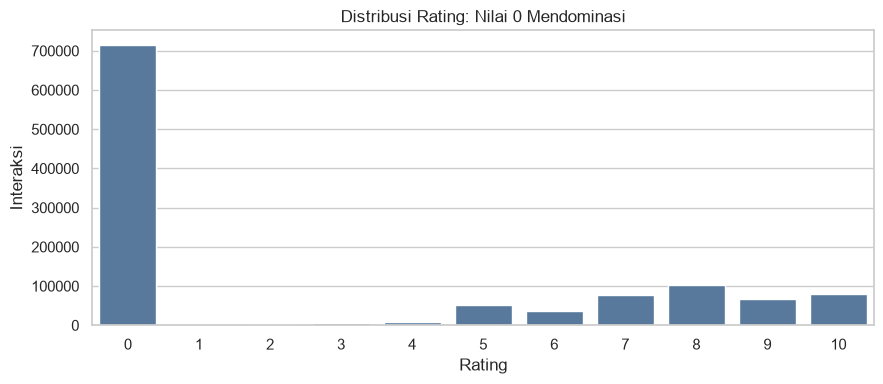

,metric,value
0,implicit/no-rating rows,716109.000000
1,explicit rating rows,433671.000000
2,implicit share,0.622823


In [5]:
missing_summary = pd.concat(
    {
        "books": raw.books.isna().sum(),
        "ratings": raw.ratings.isna().sum(),
        "users": raw.users.isna().sum(),
    },
    axis=1,
).fillna(0).astype("int64")
display(missing_summary)

rating_counts = raw.ratings["Book-Rating"].value_counts().sort_index()
implicit_rows = int((raw.ratings["Book-Rating"] == 0).sum())
explicit_raw = raw.ratings[raw.ratings["Book-Rating"] > 0].copy()

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=rating_counts.index.astype(str), y=rating_counts.values, color="#4C78A8", ax=ax)
ax.set(title="Distribusi Rating: Nilai 0 Mendominasi", xlabel="Rating", ylabel="Interaksi")
plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {
            "metric": ["implicit/no-rating rows", "explicit rating rows", "implicit share"],
            "value": [
                implicit_rows,
                len(explicit_raw),
                implicit_rows / len(raw.ratings),
            ],
        }
    )
)

### Sparsity dan Long Tail

Collaborative filtering belajar dari pola rating bersama. Jika dua buku sering
mendapat pola penilaian yang mirip dari pengguna yang sama, keduanya dianggap saling
berkaitan. Masalahnya, tidak semua pengguna memberi rating ke semua buku. Ketika
sebagian besar pasangan pengguna buku tidak mempunyai rating disebut **sparsity**.

Rating yang tersedia juga tidak tersebar merata. Sedikit buku mendapat banyak
rating, sedangkan banyak buku lainnya hanya mendapat sedikit rating. Pola ini
disebut **long tail**. Keduanya membuat pola kesamaan lebih sulit ditemukan,
terutama untuk pengguna dan buku yang hanya mempunyai sedikit riwayat rating.
Pada bagian ini, satu interaksi berarti satu rating pengguna terhadap sebuah buku.

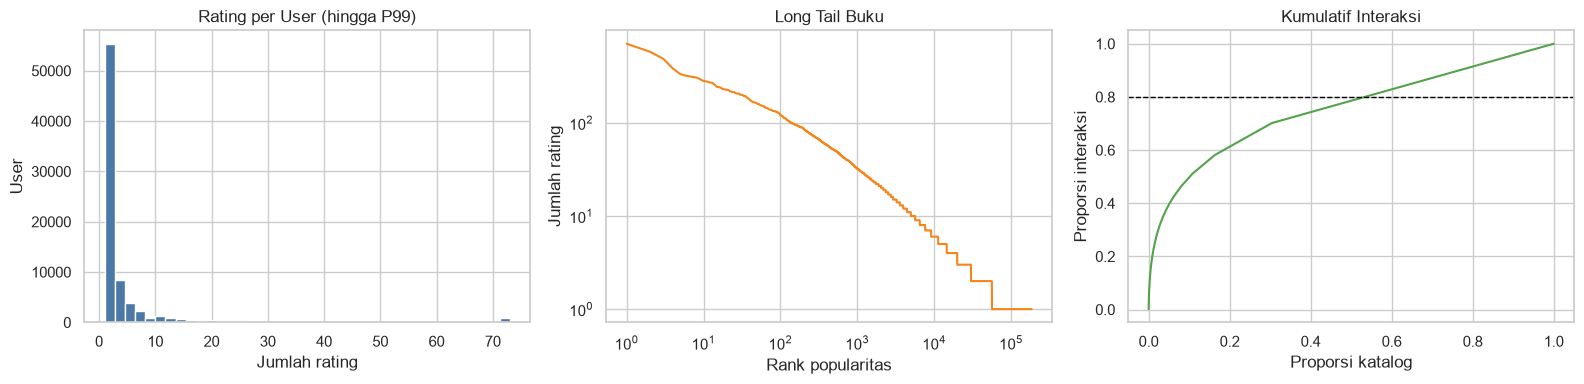

,metric,value
0,explicit matrix density,0.00003
1,unique explicit users,77805.00000
2,rated ISBN,185973.00000


,top_catalog_fraction,interaction_share
0,0.01,0.209415
1,0.05,0.395083
2,0.10,0.497449


In [6]:
raw_user_counts = explicit_raw["User-ID"].value_counts()
raw_book_counts = explicit_raw["ISBN"].astype(str).value_counts()
matrix_density = len(explicit_raw) / (
    explicit_raw["User-ID"].nunique() * explicit_raw["ISBN"].nunique()
)

ranked_book_counts = raw_book_counts.sort_values(ascending=False).reset_index(drop=True)
cumulative_share = ranked_book_counts.cumsum() / ranked_book_counts.sum()
top_share_rows = []
for fraction in (0.01, 0.05, 0.10):
    cutoff = max(1, int(np.ceil(len(ranked_book_counts) * fraction)))
    top_share_rows.append(
        {
            "top_catalog_fraction": fraction,
            "interaction_share": float(ranked_book_counts.head(cutoff).sum() / ranked_book_counts.sum()),
        }
    )

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(raw_user_counts.clip(upper=raw_user_counts.quantile(0.99)), bins=40, color="#4C78A8")
axes[0].set(title="Rating per User (hingga P99)", xlabel="Jumlah rating", ylabel="User")
axes[1].loglog(np.arange(1, len(ranked_book_counts) + 1), ranked_book_counts, color="#F58518")
axes[1].set(title="Long Tail Buku", xlabel="Rank popularitas", ylabel="Jumlah rating")
axes[2].plot(
    np.arange(1, len(cumulative_share) + 1) / len(cumulative_share),
    cumulative_share,
    color="#54A24B",
)
axes[2].axhline(0.80, color="black", linestyle="--", linewidth=1)
axes[2].set(
    title="Kumulatif Interaksi",
    xlabel="Proporsi katalog",
    ylabel="Proporsi interaksi",
)
plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {
            "metric": ["explicit matrix density", "unique explicit users", "rated ISBN"],
            "value": [matrix_density, len(raw_user_counts), len(raw_book_counts)],
        }
    )
)
display(pd.DataFrame(top_share_rows))

Grafik kiri menunjukkan jumlah rating per pengguna. Sebaran dibatasi sampai P99
agar beberapa pengguna yang sangat aktif tidak membuat pola mayoritas sulit
terlihat. Penumpukan di jumlah rating yang rendah menunjukkan bahwa banyak pengguna
hanya memberikan sedikit rating.

Grafik tengah mengurutkan buku dari yang paling banyak hingga paling sedikit
mendapat rating. Garis yang turun tajam lalu memanjang menunjukkan **long tail**:
sedikit buku sangat populer, sementara banyak buku lainnya hanya mempunyai sedikit
rating.

Grafik kanan menunjukkan seberapa besar rating terkumpul pada sebagian kecil
katalog. Sebanyak 1% buku menerima 20,9% dari seluruh rating, 5% buku menerima
39,5%, dan 10% buku menerima 49,7%. Garis putus-putus menandai 80% dari seluruh
rating.

Density matriks hanya sekitar 0,003%. Artinya, dari seluruh pasangan pengguna buku
yang mungkin terbentuk, hampir semuanya tidak memiliki rating. Jadi, **sparsity**
menunjukkan bahwa matriks rating sangat kosong, sedangkan **long tail** menunjukkan
bahwa rating yang tersedia lebih banyak terkumpul pada buku populer.

## 3. Data Preparation dan Kontrak

Pipeline membersihkan identifier, memvalidasi rating, mengagregasi pasangan
user–ISBN duplikat secara deterministik, menghapus orphan rating, menjalankan
k-core sampai konvergen, lalu memisahkan interaction catalog dari content catalog.
Buku tanpa rating masih dapat dipertahankan untuk pencarian berbasis metadata.

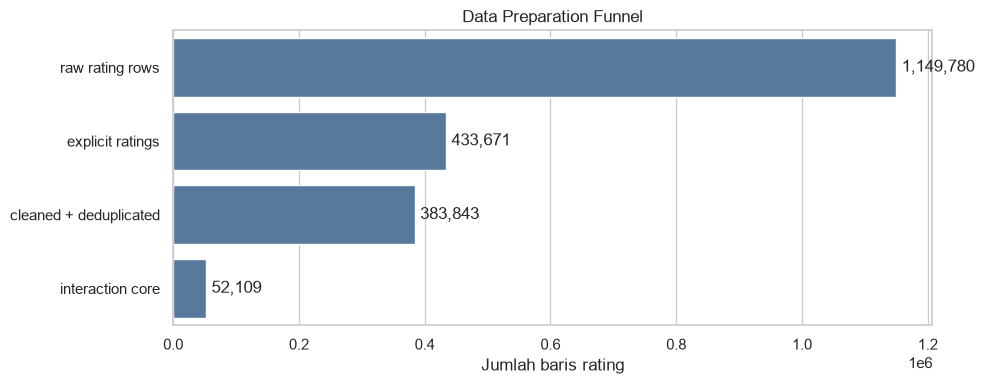

,stage,rows
0,raw rating rows,1149780
1,explicit ratings,433671
2,cleaned + deduplicated,383843
3,interaction core,52109


,value
books,3000
ratings,52109
users,278858
rated_books,1000
rating_users,9352


In [7]:
# Bersihkan dan validasi data buku, rating, serta pengguna
raw_rating_rows = len(raw.ratings)
raw_explicit_rows = len(explicit_raw)
cleaned = clean_book_dataset(raw)

del raw, explicit_raw
gc.collect()

# Bentuk data rating untuk collaborative filtering
interaction_dataset = prepare_interaction_dataset(
    books=cleaned.books,
    ratings=cleaned.ratings,
    users=cleaned.users,
    min_user_ratings=MIN_USER_RATINGS,
    min_book_ratings=MIN_BOOK_RATINGS,
    max_books=MAX_BOOKS,
    random_state=RANDOM_STATE,
)

# Tambahkan buku untuk pencarian berbasis metadata
content_books = select_content_catalog(
    cleaned.books,
    required_books=interaction_dataset.books,
    max_content_books=MAX_CONTENT_BOOKS,
)
dataset = BookDataset(
    books=content_books,
    ratings=interaction_dataset.ratings,
    users=cleaned.users,
)

# Ringkas perubahan jumlah data pada setiap tahap
funnel = pd.DataFrame(
    {
        "stage": [
            "raw rating rows",
            "explicit ratings",
            "cleaned + deduplicated",
            "interaction core",
        ],
        "rows": [
            raw_rating_rows,
            raw_explicit_rows,
            len(cleaned.ratings),
            len(dataset.ratings),
        ],
    }
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=funnel, x="rows", y="stage", color="#4C78A8", ax=ax)
ax.set(title="Data Preparation Funnel", xlabel="Jumlah baris rating", ylabel="")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=4)
plt.tight_layout()
plt.show()

display(funnel)
display(pd.Series(dataset_summary(dataset), name="value").to_frame())

Dari 1.149.780 baris rating mentah, hanya 433.671 yang berupa rating eksplisit
1–10. Setelah dibersihkan dan disaring, collaborative filtering menggunakan
52.109 rating dari 9.352 pengguna pada 1.000 buku, sedangkan katalog content-based
diperluas menjadi 3.000 buku.

Angka 278.858 menunjukkan seluruh metadata pengguna yang tetap disimpan. Hanya
9.352 pengguna di antaranya yang masuk ke data rating collaborative.

In [8]:
# Hitung jumlah rating setiap pengguna dan buku
user_degree = dataset.ratings.groupby("user_id").size()
book_degree = dataset.ratings.groupby("isbn").size()
orphan_ratings = ~dataset.ratings["isbn"].isin(dataset.books["isbn"])
duplicate_pairs = dataset.ratings.duplicated(["user_id", "isbn"])

# Pastikan data memenuhi kontrak sebelum digunakan model
contract_checks = pd.DataFrame(
    {
        "contract": [
            "rating finite and in [1, 10]",
            "no duplicate user–ISBN",
            "every rating has book metadata",
            f"minimum user degree >= {MIN_USER_RATINGS}",
            f"minimum item degree >= {MIN_BOOK_RATINGS}",
            "interaction catalog is contained in content catalog",
        ],
        "passed": [
            bool(
                np.isfinite(dataset.ratings["book_rating"]).all()
                and dataset.ratings["book_rating"].between(1, 10).all()
            ),
            not bool(duplicate_pairs.any()),
            not bool(orphan_ratings.any()),
            bool(user_degree.min() >= MIN_USER_RATINGS),
            bool(book_degree.min() >= MIN_BOOK_RATINGS),
            set(interaction_dataset.books["isbn"]).issubset(set(dataset.books["isbn"])),
        ],
    }
)
display(contract_checks)

# Hentikan proses jika ada kontrak yang gagal
assert contract_checks["passed"].all(), "Prepared dataset violates a documented contract."

,contract,passed
0,"rating finite and in [1, 10]",True
1,no duplicate user–ISBN,True
2,every rating has book metadata,True
3,minimum user degree >= 2,True
4,minimum item degree >= 2,True
5,interaction catalog is contained in content catalog,True


Keenam pemeriksaan berhasil dilewati. Artinya, data tidak memiliki rating tidak
valid, pasangan pengguna–ISBN duplikat, atau rating tanpa metadata buku. Setiap
pengguna dan buku dalam collaborative filtering juga memiliki minimal dua rating.
Jika salah satu pemeriksaan gagal, proses akan langsung dihentikan.

### Satu ISBN belum tentu satu buku yang unik

ISBN menandai edisi atau format tertentu, sehingga paperback dan hardcover dari
buku yang sama bisa memiliki ISBN berbeda. Edisi tersebut perlu digabung agar
rekomendasi tidak menampilkan buku yang sama berulang kali dan hasil evaluasi tidak
terlihat lebih baik hanya karena edisi lain masih tersedia sebagai kandidat.

In [9]:
catalog_with_work = dataset.books[["isbn", "book_title", "book_author"]].copy()
catalog_with_work["work_key"] = [
    book_work_key(row.book_title, row.book_author, row.isbn)
    for row in catalog_with_work.itertuples(index=False)
]
edition_counts = catalog_with_work.groupby("work_key").size().sort_values(ascending=False)
multi_edition_keys = edition_counts[edition_counts > 1].head(5).index

display(
    pd.DataFrame(
        {
            "unit": ["ISBN/edition", "canonical work", "multi-edition works"],
            "count": [
                len(catalog_with_work),
                catalog_with_work["work_key"].nunique(),
                int((edition_counts > 1).sum()),
            ],
        }
    )
)
display(
    catalog_with_work[catalog_with_work["work_key"].isin(multi_edition_keys)]
    .sort_values(["work_key", "isbn"])
    .head(15)
)

,unit,count
0,ISBN/edition,3000
1,canonical work,2816
2,multi-edition works,167


,isbn,book_title,book_author,work_key
1371,0002558122,Angelas Ashes,Frank Mccourt,title:angelas ashes|author:frank mccourt
190,000649840X,Angelas Ashes,Frank Mccourt,title:angelas ashes|author:frank mccourt
1806,000649840x,Angelas Ashes,Frank Mccourt,title:angelas ashes|author:frank mccourt
569,014028009X,Bridget Jones's Diary,Helen Fielding,title:bridget jones s diary|author:helen fielding
730,0141000198,Bridget Jones's Diary,Helen Fielding,title:bridget jones s diary|author:helen fielding
34,0330332775,Bridget Jones's Diary,Helen Fielding,title:bridget jones s diary|author:helen fielding
842,0670880728,Bridget Jones's Diary,Helen Fielding,title:bridget jones s diary|author:helen fielding
135,0385420161,"Like Water for Chocolate: A Novel in Monthly Installments, With Recipes, Romances, and...",Laura Esquivel,title:like water for chocolate a novel in monthly installments with recipes romances a...
870,038542017X,"Like Water for Chocolate : A Novel in Monthly Installments with Recipes, Romances, and...",LAURA ESQUIVEL,title:like water for chocolate a novel in monthly installments with recipes romances a...
412,0385474016,"Like Water for Chocolate: A Novel in Monthly Installments With Recipes, Romances and H...",Laura Esquivel,title:like water for chocolate a novel in monthly installments with recipes romances a...


## 4. Baseline Pertama (Popularity)

Sebelum personalisasi, sistem perlu baseline yang murah dan selalu tersedia.
Skor popularity menggunakan `mean_rating × log1p(rating_count)`, sehingga sebuah
buku dengan satu rating 10 tidak otomatis mengalahkan buku yang konsisten disukai
banyak pengguna.

In [10]:
popularity = (
    dataset.ratings.groupby("isbn")
    .agg(mean_rating=("book_rating", "mean"), rating_count=("book_rating", "size"))
    .reset_index()
)
popularity["score"] = popularity["mean_rating"] * np.log1p(popularity["rating_count"])
popularity = (
    popularity.merge(dataset.books, on="isbn", how="left")
    .sort_values(["score", "rating_count", "isbn"], ascending=[False, False, True])
    .reset_index(drop=True)
)
display(
    popularity[
        ["score", "mean_rating", "rating_count", "isbn", "book_title", "book_author"]
    ].head(TOP_K)
)

,score,mean_rating,rating_count,isbn,book_title,book_author
0,50.827845,8.246836,474,0316666343,The Lovely Bones: A Novel,Alice Sebold
1,50.418451,8.529891,368,0385504209,The Da Vinci Code,Dan Brown
2,49.097076,8.938017,242,059035342X,Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback)),J. K. Rowling
3,46.688186,9.101191,168,043935806X,Harry Potter and the Order of the Phoenix (Book 5),J. K. Rowling
4,46.521795,8.534483,232,0142001740,The Secret Life of Bees,Sue Monk Kidd
5,45.940752,8.267442,258,0312195516,The Red Tent (Bestselling Backlist),Anita Diamant
6,45.804240,9.025157,159,0446310786,To Kill a Mockingbird,Harper Lee
7,45.135520,9.317460,126,0439139597,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling
8,44.793152,8.858974,156,0439064872,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling
9,44.251267,9.134921,126,0439136350,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling


Popularity tidak pernah mengalami cold-user dan latency-nya rendah, tetapi tidak
personal. Ia juga berisiko memperkuat pola *rich get richer*. Karena itu popularity
cocok sebagai fallback/alternatif dan baseline pembanding, bukan otomatis jawaban akhir.

## 5. Collaborative Filtering

Item-based collaborative filtering membangun sparse matrix buku × user. Rating
dikoreksi terhadap rata-rata user yang diregularisasi, lalu model mencari item
dengan pola rating serupa. Hanya rating `>= 8` yang menjadi positive seed.

In [11]:
collab_model = ItemBasedCollaborativeRecommender(
    n_neighbors=N_NEIGHBORS,
    positive_rating_threshold=POSITIVE_RATING_THRESHOLD,
).fit(dataset.books, dataset.ratings)

isbn_to_work = work_key_map(dataset.books)
positive_history = dataset.ratings[
    dataset.ratings["book_rating"] >= POSITIVE_RATING_THRESHOLD
].copy()
positive_history["work_key"] = positive_history["isbn"].astype(str).map(isbn_to_work)
positive_work_counts = positive_history.groupby("user_id")["work_key"].nunique()

# Pilih user secara deterministik dengan histori cukup kaya namun tetap mudah dibaca.
moderate_users = positive_work_counts[(positive_work_counts >= 3) & (positive_work_counts <= 20)]
candidate_pool = moderate_users if not moderate_users.empty else positive_work_counts
candidate_user_id = int(
    candidate_pool.rename("positive_works")
    .reset_index()
    .sort_values(["positive_works", "user_id"], ascending=[False, True])
    .iloc[0]["user_id"]
)

user_history = (
    dataset.ratings[dataset.ratings["user_id"] == candidate_user_id]
    .sort_values(["book_rating", "isbn"], ascending=[False, True])
    .merge(dataset.books, on="isbn", how="left")
)
display(user_history[["isbn", "book_title", "book_author", "book_rating"]].head(15))

,isbn,book_title,book_author,book_rating
0,0060392452,Stupid White Men ...and Other Sorry Excuses for the State of the Nation!,Michael Moore,10.0
1,0140067477,The Tao of Pooh,Benjamin Hoff,10.0
2,0380813815,"Lamb : The Gospel According to Biff, Christ's Childhood Pal",Christopher Moore,10.0
3,0394820371,The Phantom Tollbooth,Norton Juster,10.0
4,0439136350,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,10.0
5,0439139597,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,10.0
6,0440487617,A Wind in the Door,Madeleine L'Engle,10.0
7,0440498058,A Wrinkle In Time,MADELEINE L'ENGLE,10.0
8,0440998050,A Wrinkle in Time,Madeleine L'Engle,10.0
9,0441003257,Good Omens,Neil Gaiman,10.0


In [12]:
strict_collaborative = collab_model.score_for_user(
    candidate_user_id,
    seed_items=5,
    candidate_pool_size=100,
)
served_collaborative = collab_model.recommend_for_user(candidate_user_id, top_n=TOP_K)

display(
    pd.DataFrame(
        {
            "user_id": [candidate_user_id],
            "positive_canonical_works": [int(positive_work_counts[candidate_user_id])],
            "strict_collaborative_candidates": [len(strict_collaborative)],
            "served_recommendations": [len(served_collaborative)],
            "fallback_or_filler_possible": [len(strict_collaborative) < TOP_K],
        }
    )
)
display(
    served_collaborative[
        ["score", "isbn", "book_title", "book_author", "publisher"]
    ].head(TOP_K)
)

,user_id,positive_canonical_works,strict_collaborative_candidates,served_recommendations,fallback_or_filler_possible
0,6251,20,100,10,False


,score,isbn,book_title,book_author,publisher
0,0.442325,0439064864,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,Scholastic
1,0.378919,0590353403,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,Scholastic
2,0.201885,0451169522,Misery,Stephen King,Penguin USA (Paper)
3,0.185600,0385334036,The Smoke Jumper,Nicholas Evans,Delacorte Press
4,0.162824,0425177173,Atlantis Found,Clive Cussler,Berkley Publishing Group
5,0.157975,0452269571,Bastard Out of Carolina,Dorothy Allison,Plume Books
6,0.157381,0316603570,3rd Degree,James Patterson,"Little, Brown"
7,0.155608,0451207521,Jackdaws,Ken Follett,Signet Book
8,0.147447,0894808249,All I Need to Know I Learned from My Cat,Suzy Becker,Workman Publishing
9,0.146437,0553584510,The Survivors Club,LISA GARDNER,Bantam


User 6251 memiliki 20 karya dengan rating minimal 8, sehingga contoh ini mewakili
pengguna dengan riwayat yang cukup kaya. Collaborative filtering menghasilkan 100
kandidat dan dapat mengisi 10 rekomendasi tanpa fallback. Setelah pengguna memberi
rating tinggi pada beberapa buku Harry Potter, dua rekomendasi teratasnya adalah
buku lain dari seri tersebut.

## 6. Content-Based filtering

Metadata tetap tersedia meskipun sebuah item belum memiliki banyak interaksi.
Model content mengubah `title + author + publisher` menjadi TF-IDF unigram/bigram,
lalu mencari cosine-neighbor dan mendeduplikasi canonical work.

In [13]:
content_model = ContentBasedRecommender().fit(dataset.books)
query_title = "Adventures of Huckleberry Finn"
if query_title not in set(dataset.books["book_title"]):
    query_title = str(dataset.books.sort_values("isbn").iloc[0]["book_title"])

content_recommendations = content_model.recommend_similar(
    title=query_title,
    top_n=TOP_K,
)
display(
    content_recommendations[
        ["score", "isbn", "book_title", "book_author", "publisher"]
    ]
)

,score,isbn,book_title,book_author,publisher
0,0.133710,0020429819,The Macmillan Illustrated Encyclopedia of Dinosaurs and Prehistoric Animals: A Visual ...,Dougal Dixon,Macmillan General Reference
1,0.131637,0020811608,Genealogist's Encyclopedia,Leslie G. Pine,Simon &amp; Schuster
2,0.103506,0002219476,The way to dusty death,Alistair MacLean,Collins
3,0.099652,0027357813,A Long Way from Verona,Jane Gardam,Simon &amp; Schuster (J)
4,0.098948,0026284707,Men at Work: The Craft of Baseball,George F. Will,Simon &amp; Schuster
5,0.098326,0004116941,Collins Encyclopedia of Fishing in Britain and Ireland,Michael Prichard,HarperCollins Publishers
6,0.089439,0025439472,The Shepherd,Joseph F. Girzone,Simon &amp; Schuster
7,0.089393,0007122217,Illustrated Daughters of Britannia,Katie Hickman,HarperCollins Illustrated
8,0.086254,0027255107,The Winter of the Birds,Helen Cresswell,Simon &amp; Schuster Merchandise &amp;
9,0.085843,0027334635,Fishing,Diana Engel,Simon &amp; Schuster


Pada contoh ini, skor kemiripan tertinggi hanya 0,134 dan buku yang muncul tidak
terlihat memiliki tema yang dekat dengan *Adventures of Huckleberry Finn*. Beberapa
hasil justru memiliki nama penerbit yang sama atau mirip. Ini menunjukkan bahwa
content-based dapat bekerja tanpa riwayat rating, tetapi metadata judul, penulis,
dan penerbit saja belum tentu cukup untuk memahami isi buku.

## 7. Hybrid (Gabungan)
Hybrid menggabungkan collaborative, content profile, dan popularity setelah
masing-masing dinormalisasi. Bobot dasar adalah 0,40 / 0,45 / 0,15, lalu dapat
bergeser berdasarkan jumlah positive canonical works milik user.

In [14]:
hybrid_model = HybridRecommender(
    n_neighbors=N_NEIGHBORS,
    collaborative_weight=0.40,
    content_weight=0.45,
    popularity_weight=0.15,
    dynamic_weights=True,
    positive_rating_threshold=POSITIVE_RATING_THRESHOLD,
).fit(dataset.books, dataset.ratings)

hybrid_recommendations = hybrid_model.recommend_for_user(
    candidate_user_id,
    top_n=TOP_K,
)
display(
    hybrid_recommendations[
        [
            "score",
            "collaborative_score",
            "content_score",
            "popularity_score",
            "source",
            "reason",
            "isbn",
            "book_title",
            "book_author",
        ]
    ]
)

,score,collaborative_score,content_score,popularity_score,source,reason,isbn,book_title,book_author
0,0.763936,1.000000,0.525982,0.848296,collaborative,Item-rating patterns are similar to books the user rated 8/10 or higher.,0439064864,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling
1,0.706356,0.856653,0.529889,0.834962,collaborative,Item-rating patterns are similar to books the user rated 8/10 or higher.,0590353403,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling
2,0.425865,0.287210,0.369086,0.965948,content,Metadata is similar to books the user rated 8/10 or higher.,059035342X,Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback)),J. K. Rowling
3,0.293000,0.456418,0.048663,0.590229,collaborative,Item-rating patterns are similar to books the user rated 8/10 or higher.,0451169522,Misery,Stephen King
4,0.292936,0.245098,0.263022,0.510241,content,Metadata is similar to books the user rated 8/10 or higher.,0380728133,Bloodsucking Fiends: A Love Story,Christopher Moore
5,0.261296,0.357147,0.046747,0.649339,collaborative,Item-rating patterns are similar to books the user rated 8/10 or higher.,0452269571,Bastard Out of Carolina,Dorothy Allison
6,0.249186,0.156672,0.228349,0.558403,content,Metadata is similar to books the user rated 8/10 or higher.,0140177396,Of Mice and Men (Penguin Great Books of the 20th Century),John Steinbeck
7,0.248498,0.419602,0.024658,0.463743,collaborative,Item-rating patterns are similar to books the user rated 8/10 or higher.,0385334036,The Smoke Jumper,Nicholas Evans
8,0.247534,0.200080,0.142826,0.688202,popularity,Popularity is the strongest signal in this blended recommendation.,0140298479,Bridget Jones: The Edge of Reason,Helen Fielding
9,0.239959,0.325537,0.053182,0.572082,collaborative,Item-rating patterns are similar to books the user rated 8/10 or higher.,0316168815,The Lovely Bones,Alice Sebold


Dari 10 rekomendasi, enam didominasi collaborative, tiga content, dan satu
popularity. Kolom `source` menunjukkan sinyal terkuat, sedangkan skor akhirnya
tetap merupakan gabungan ketiganya. Dua edisi *Harry Potter and the Sorcerer's
Stone* masih muncul bersamaan, yang menunjukkan bahwa deduplikasi berbasis
judul–penulis belum selalu berhasil mengenali variasi judul.

### Failure Mode

Tiga skenario berikut menunjukkan cara hybrid menyesuaikan bobot. 

Pengguna tanpa riwayat mendapat rekomendasi popularity. Untuk pengguna yang baru memiliki 1–2
karya dengan rating minimal 8, bobot collaborative dikurangi dan content diperbesar.
Pengguna dengan lebih dari 5 karya positif memakai bobot dasar 40% collaborative,
45% content, dan 15% popularity. Sinyal dengan bobot terbesar belum tentu menjadi
sumber dominan pada setiap buku.

In [15]:
# Siapkan pengguna tanpa riwayat, dengan riwayat tipis, dan dengan riwayat kaya.
sparse_user_id = int(
    positive_work_counts.rename("positive_works")
    .reset_index()
    .sort_values(["positive_works", "user_id"], ascending=[True, True])
    .iloc[0]["user_id"]
)
cold_user_id = int(dataset.ratings["user_id"].max()) + 1_000_000


def effective_signal_weights(user_id, positive_works):
    """Baca bobot yang dipakai oleh routing hybrid untuk keperluan diagnosis."""
    user_history = dataset.ratings[dataset.ratings["user_id"] == user_id].copy()
    if user_history.empty:
        return {"collaborative": 0.0, "content": 0.0, "popularity": 1.0}

    collaborative_scores = hybrid_model._collaborative_scores(
        user_id=user_id,
        seed_items=5,
        candidate_pool_size=500,
    )
    content_scores = hybrid_model._content_profile_scores(user_history, seed_items=5)
    return hybrid_model._weights_for_history(
        positive_works,
        content_scores,
        collaborative_scores,
        allow_popularity_fallback=True,
    )


# Bandingkan bobot efektif dengan sumber terkuat pada hasil Top-N.
scenario_rows = []
for scenario, user_id in (
    ("cold", cold_user_id),
    ("sparse-positive", sparse_user_id),
    ("richer-positive", candidate_user_id),
):
    history_rows = int((dataset.ratings["user_id"] == user_id).sum())
    positive_works = int(positive_work_counts.get(user_id, 0))
    weights = effective_signal_weights(user_id, positive_works)
    recommendations = hybrid_model.recommend_for_user(user_id, top_n=TOP_K)
    source_counts = recommendations["source"].value_counts()
    scenario_rows.append(
        {
            "scenario": scenario,
            "user_id": user_id,
            "history_rows": history_rows,
            "positive_works": positive_works,
            "recommendations": len(recommendations),
            "collaborative_weight": weights["collaborative"],
            "content_weight": weights["content"],
            "popularity_weight": weights["popularity"],
            "dominant_source": source_counts.index[0] if not source_counts.empty else "empty",
            "popularity_dominant_share": float(
                source_counts.get("popularity", 0) / max(1, len(recommendations))
            ),
        }
    )
display(pd.DataFrame(scenario_rows))

,scenario,user_id,history_rows,positive_works,recommendations,dominant_source,popularity_share
0,cold,1278854,0,0,10,popularity,1.0
1,sparse-positive,99,2,1,10,collaborative,0.4
2,richer-positive,6251,35,20,10,collaborative,0.1


Cold user tetap mendapat 10 rekomendasi, tetapi seluruhnya mengandalkan popularity.
Pada sparse user, popularity menjadi sinyal terkuat untuk 4 dari 10 buku, sedangkan
pada pengguna dengan riwayat kaya jumlahnya turun menjadi 1 dari 10. Hasil ini
menunjukkan bahwa ketergantungan pada popularity berkurang ketika riwayat pengguna
semakin kaya.

## 8. Cara Evaluasi Dilakukan

Evaluasi dibagi menjadi **validation** dan **test**. Validation dipakai untuk
mencoba dan membandingkan konfigurasi model. Test disimpan dan baru dibuka setelah
keputusan selesai, agar hasil akhirnya tidak bias karena test ikut dipakai memilih
model.

Pada diagnostic ini, 40 kasus holdout dibagi menjadi 20 kasus validation dan 20
kasus test. Sampelnya sengaja kecil agar prosesnya cepat dijalankan dan alur
evaluasinya mudah diperiksa. Tujuannya belum untuk menentukan model terbaik, tetapi
memastikan penyembunyian buku target, pembentukan katalog dari data train, dan
perhitungan metrik berjalan tanpa kebocoran data.

Dua code box berikut hanya menggunakan validation. Test tetap disimpan untuk
evaluasi akhir, sedangkan keputusan model nantinya menggunakan repeated validation
dengan sampel yang lebih besar.

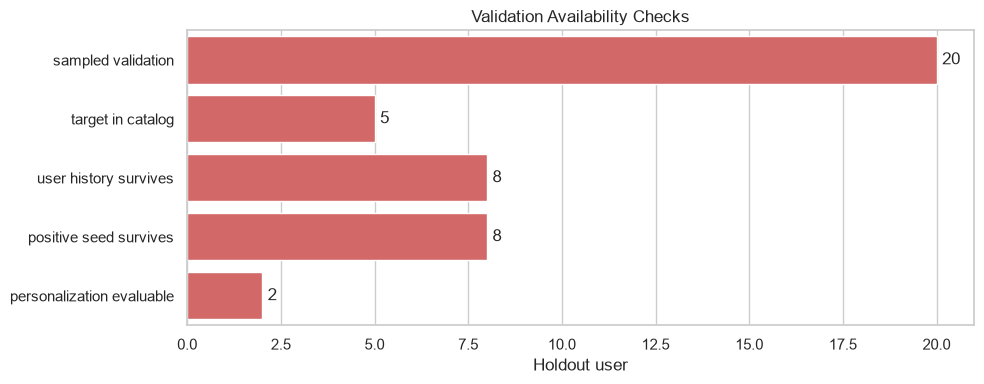

,check,users
0,sampled validation,20
1,target in catalog,5
2,user history survives,8
3,positive seed survives,8
4,personalization evaluable,2


,partition,holdouts
0,validation diagnostic,20
1,reserved test (untouched),20


In [16]:
evaluation_data = prepare_validation_test_evaluation(
    cleaned,
    sample_users=EVALUATION_SAMPLE_USERS,
    validation_fraction=0.5,
    min_user_ratings=MIN_USER_RATINGS,
    min_book_ratings=MIN_BOOK_RATINGS,
    max_books=MAX_BOOKS,
    max_content_books=MAX_CONTENT_BOOKS,
    random_state=RANDOM_STATE,
)
train_dataset = evaluation_data.train_dataset
validation_holdouts = evaluation_data.validation_holdout_ratings.copy()

eval_isbn_to_work = work_key_map(train_dataset.books)
eval_catalog_works = set(eval_isbn_to_work.values())
eval_history_users = set(train_dataset.ratings["user_id"].astype(int))
eval_positive_users = set(
    train_dataset.ratings.loc[
        train_dataset.ratings["book_rating"] >= POSITIVE_RATING_THRESHOLD,
        "user_id",
    ].astype(int)
)

validation_holdouts["candidate_available"] = validation_holdouts["work_key"].isin(
    eval_catalog_works
)
validation_holdouts["history_available"] = validation_holdouts["user_id"].isin(
    eval_history_users
)
validation_holdouts["positive_seed_available"] = validation_holdouts["user_id"].isin(
    eval_positive_users
)
validation_holdouts["personalization_evaluable"] = (
    validation_holdouts["candidate_available"]
    & validation_holdouts["history_available"]
    & validation_holdouts["positive_seed_available"]
)

availability_checks = pd.DataFrame(
    {
        "check": [
            "sampled validation",
            "target in catalog",
            "user history survives",
            "positive seed survives",
            "personalization evaluable",
        ],
        "users": [
            len(validation_holdouts),
            int(validation_holdouts["candidate_available"].sum()),
            int(validation_holdouts["history_available"].sum()),
            int(validation_holdouts["positive_seed_available"].sum()),
            int(validation_holdouts["personalization_evaluable"].sum()),
        ],
    }
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=availability_checks, x="users", y="check", color="#E45756", ax=ax)
ax.set(title="Validation Availability Checks", xlabel="Holdout user", ylabel="")
for container in ax.containers:
    ax.bar_label(container, padding=4)
plt.tight_layout()
plt.show()

display(availability_checks)
display(
    pd.DataFrame(
        {
            "partition": ["validation diagnostic", "reserved test (untouched)"],
            "holdouts": [
                len(evaluation_data.validation_holdout_ratings),
                len(evaluation_data.test_holdout_ratings),
            ],
        }
    )
)

Dari 20 kasus validasi, buku target hanya tersedia di katalog pada 5 kasus.
Setelah ketersediaan target, riwayat pengguna, dan karya positif diperiksa bersama,
hanya 2 kasus yang dapat dipakai untuk menilai personalisasi. Jadi, sebagian besar
kasus gagal sebelum model sempat mengurutkan buku.

In [17]:
eval_hybrid = HybridRecommender(
    n_neighbors=N_NEIGHBORS,
    collaborative_weight=0.40,
    content_weight=0.45,
    popularity_weight=0.15,
    dynamic_weights=True,
    positive_rating_threshold=POSITIVE_RATING_THRESHOLD,
).fit(train_dataset.books, train_dataset.ratings)
eval_collaborative = eval_hybrid.collaborative_model

validation_metric_rows = []
for row in validation_holdouts.itertuples(index=False):
    user_id = int(row.user_id)
    relevant = [str(row.work_key)]
    train_history = train_dataset.ratings[train_dataset.ratings["user_id"] == user_id]
    recommendations_by_model = {
        "hybrid": recommendation_work_keys(
            eval_hybrid.recommend_for_user(user_id, top_n=TOP_K),
            eval_isbn_to_work,
        ),
        "collaborative + fallback": recommendation_work_keys(
            eval_collaborative.recommend_for_user(user_id, top_n=TOP_K),
            eval_isbn_to_work,
        ),
        "popularity": recommendation_work_keys(
            eval_collaborative.recommend_popular(
                top_n=TOP_K,
                exclude_isbns=set(train_history["isbn"].astype(str)),
            ),
            eval_isbn_to_work,
        ),
    }
    for model_name, recommended in recommendations_by_model.items():
        validation_metric_rows.append(
            {
                "model": model_name,
                "user_id": user_id,
                "candidate_available": bool(row.candidate_available),
                "positive_seed_available": bool(row.positive_seed_available),
                **ranking_metrics_at_k(recommended, relevant, TOP_K),
            }
        )

validation_metrics = pd.DataFrame(validation_metric_rows)
metric_columns = [
    f"precision_at_{TOP_K}",
    f"recall_at_{TOP_K}",
    f"hit_rate_at_{TOP_K}",
    f"map_at_{TOP_K}",
    f"mrr_at_{TOP_K}",
    f"ndcg_at_{TOP_K}",
]
end_to_end_validation = validation_metrics.groupby("model")[metric_columns].mean()
conditional_validation_rows = validation_metrics[
    validation_metrics["candidate_available"]
    & validation_metrics["positive_seed_available"]
]
conditional_validation = conditional_validation_rows.groupby("model")[metric_columns].mean()

validation_summary = end_to_end_validation.reset_index()[
    ["model", f"hit_rate_at_{TOP_K}", f"ndcg_at_{TOP_K}"]
].melt(id_vars="model", var_name="metric", value_name="value")
if bool((validation_summary["value"] > 0).any()):
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(data=validation_summary, x="model", y="value", hue="metric", ax=ax)
    ax.set(
        title=f"Validation Diagnostic Only (n={len(validation_holdouts)})",
        xlabel="",
        ylabel="Metric",
    )
    ax.tick_params(axis="x", rotation=12)
    plt.tight_layout()
    plt.show()
else:
    print(
        "No Top-K hits occurred in this small validation diagnostic. "
        "Use the repeated benchmark below for model-selection evidence."
    )

display(
    {
        "end_to_end": end_to_end_validation,
        "conditional": conditional_validation,
        "conditional_users": int(conditional_validation_rows["user_id"].nunique()),
    }
)

No Top-K hits occurred in this small validation diagnostic. Use the repeated benchmark below for model-selection evidence.


{'end_to_end':                           precision_at_10  recall_at_10  hit_rate_at_10  \
 model                                                                     
 collaborative + fallback              0.0           0.0             0.0   
 hybrid                                0.0           0.0             0.0   
 popularity                            0.0           0.0             0.0   
 
                           map_at_10  mrr_at_10  ndcg_at_10  
 model                                                       
 collaborative + fallback        0.0        0.0         0.0  
 hybrid                          0.0        0.0         0.0  
 popularity                      0.0        0.0         0.0  ,
 'conditional':                           precision_at_10  recall_at_10  hit_rate_at_10  \
 model                                                                     
 collaborative + fallback              0.0           0.0             0.0   
 hybrid                                0.0        

Tidak ada buku target yang ditemukan dalam Top-10, baik oleh hybrid, collaborative,
maupun popularity. Namun sampel ini hanya berisi 20 kasus dan hanya 2 yang dapat
menilai personalisasi, sehingga hasil nol tersebut belum cukup untuk membandingkan
model. Keputusan bobot harus memakai repeated validation, sedangkan fixed test baru
dibuka setelah keputusan selesai.

## 9. Memeriksa Catatan Evaluasi pada Model Serving

Bagian sebelumnya menjelaskan cara evaluasi dilakukan. Sekarang kita tidak
menjalankan evaluasi baru, tetapi membaca manifest yang menyertai model serving.
Manifest tersebut mencatat identitas model, konfigurasi, serta hasil evaluasi ketika
bundle dibuat.

Catatan ini memastikan angka evaluasi tidak terpisah dari model yang benar-benar
digunakan. Namun kekuatan buktinya tetap perlu diperiksa sebelum hasilnya dianggap
sebagai klaim performa.

In [18]:
manifest_path = MODEL_ARTIFACT.with_name(f"{MODEL_ARTIFACT.name}.manifest.json")
manifest_payload = json.loads(manifest_path.read_text(encoding="utf-8"))
deployment_evidence = manifest_payload.get("metrics", {})
deployment_availability = deployment_evidence.get("availability", {})

evidence_strength = pd.DataFrame(
    {
        "metric": [
            "sampled holdouts",
            "target available",
            "history evaluable",
            "personalization evaluable",
            "bootstrap resamples",
        ],
        "value": [
            deployment_availability.get("sampled_holdouts", 0),
            deployment_availability.get("candidate_available_holdouts", 0),
            deployment_availability.get("history_evaluable_holdouts", 0),
            deployment_availability.get("personalization_evaluable_holdouts", 0),
            next(
                (
                    interval.get("n_resamples", 0)
                    for model_intervals in deployment_evidence.get(
                        "confidence_intervals",
                        {},
                    ).values()
                    for scope_intervals in model_intervals.values()
                    for interval in scope_intervals.values()
                ),
                0,
            ),
        ],
    }
)
display(evidence_strength)
print("Evidence label: PILOT — useful for pipeline verification, not a performance claim.")

,metric,value
0,sampled holdouts,10
1,target available,4
2,history evaluable,2
3,personalization evaluable,2
4,bootstrap resamples,100


Evidence label: PILOT — useful for pipeline verification, not a performance claim.


Evidence dalam bundle masih sangat kecil. Dari 10 kasus, hanya 4 buku target
tersedia di katalog dan hanya 2 kasus dapat menilai personalisasi. Karena itu,
hasil ini dipakai untuk memverifikasi pipeline serving, bukan menyatakan model
sudah unggul.

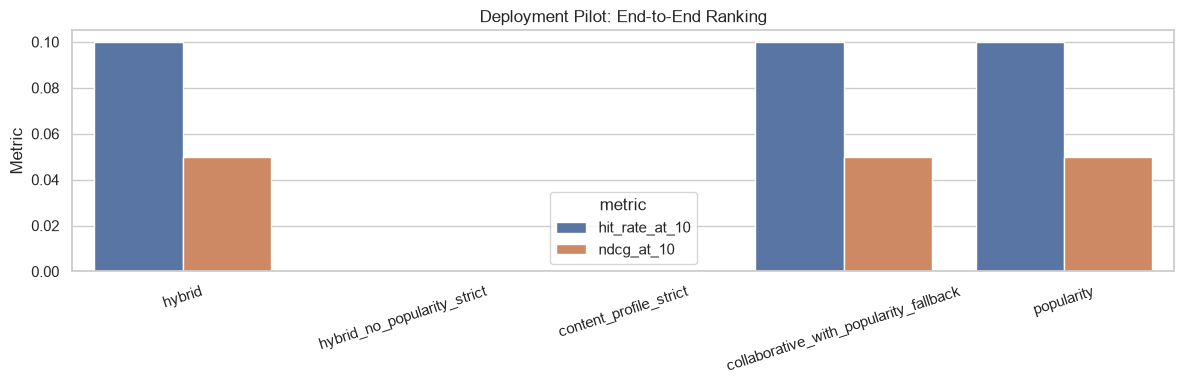

,model,sample_size,hit_rate_at_10,ndcg_at_10
0,hybrid,10,0.1,0.05
1,hybrid_no_popularity_strict,10,0.0,0.00
2,content_profile_strict,10,0.0,0.00
3,collaborative_with_popularity_fallback,10,0.1,0.05
4,popularity,10,0.1,0.05


In [19]:
pilot_summary = pd.DataFrame(deployment_evidence.get("summary", {}).get("end_to_end", []))
if not pilot_summary.empty:
    pilot_metric_columns = [
        column
        for column in (f"hit_rate_at_{TOP_K}", f"ndcg_at_{TOP_K}")
        if column in pilot_summary.columns
    ]
    pilot_plot = pilot_summary.melt(
        id_vars=["model", "sample_size"],
        value_vars=pilot_metric_columns,
        var_name="metric",
        value_name="value",
    )
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.barplot(data=pilot_plot, x="model", y="value", hue="metric", ax=ax)
    ax.set(title="Deployment Pilot: End-to-End Ranking", xlabel="", ylabel="Metric")
    ax.tick_params(axis="x", rotation=18)
    plt.tight_layout()
    plt.show()
    display(pilot_summary[["model", "sample_size", *pilot_metric_columns]])

Hybrid, collaborative dengan fallback, dan popularity sama-sama menemukan 1 dari
10 target dengan NDCG@10 sebesar 0,05. Hybrid tanpa popularity dan content strict
tidak menemukan target. Sampel ini belum cukup untuk membuktikan hybrid lebih baik,
ia hanya menunjukkan bahwa fallback berperan penting pada pilot ini.

## 10. Memilih Komposisi Bobot Hybrid

Bagian ini menentukan apakah komposisi bobot hybrid perlu diganti. Baseline
menggunakan 40% collaborative, 45% content, dan 15% popularity. Sebagai penantang,
kita mencoba memperbesar content menjadi 60%, mengurangi collaborative menjadi 30%,
dan popularity menjadi 10%. Challenger hanya akan menggantikan baseline jika
hasilnya lebih baik dan cukup konsisten.

Pengujiannya dilakukan melalui langkah berikut:

1. Fixed test dipisahkan sekali dan tidak digunakan selama pemilihan model.
2. Lima validation split dibuat dari development users, masing-masing berisi 200
   kasus holdout.
3. Pada setiap kasus, satu karya disembunyikan dan seluruh edisinya dikeluarkan
   dari data train.
4. Baseline dan challenger diuji pada pasangan pengguna–buku yang sama.
5. Selisih keduanya diperiksa menggunakan paired bootstrap dan selection gate.
6. Challenger dipilih hanya jika peningkatannya cukup besar dan konsisten. Jika
   tidak, baseline dipertahankan.
7. Fixed test dibuka sekali untuk konfigurasi yang sudah ditetapkan.

In [21]:
benchmark_candidates = [
    BENCHMARK_ARTIFACT,
    PROJECT_ROOT
    / "artifacts"
    / "verification"
    / "repeated_split_hybrid_benchmark_schema_v2_smoke.json",
]
benchmark_path = next((path for path in benchmark_candidates if path.exists()), None)
benchmark_payload = None

if benchmark_path is None:
    print(
        "Formal benchmark artifact is not available. Run `uv run book-rec benchmark-hybrid` "
        "to populate this section."
    )
else:
    verified_benchmark = read_benchmark_metrics(benchmark_path)
    benchmark_payload = json.loads(benchmark_path.read_text(encoding="utf-8"))
    parameters = benchmark_payload["parameters"]
    is_portfolio_scale = (
        int(parameters["validation_users"]) >= 200
        and int(parameters["test_users"]) >= 200
        and int(parameters["repetitions"]) >= 5
        and int(parameters["bootstrap_resamples"]) >= 2_000
    )
    display(
        pd.DataFrame(
            {
                "field": [
                    "artifact",
                    "protocol",
                    "validation users / repeat",
                    "fixed-test users",
                    "repetitions",
                    "bootstrap resamples",
                    "evidence label",
                ],
                "value": [
                    display_path(benchmark_path, PROJECT_ROOT),
                    benchmark_payload["protocol"],
                    parameters["validation_users"],
                    parameters["test_users"],
                    parameters["repetitions"],
                    parameters["bootstrap_resamples"],
                    "PORTFOLIO-SCALE" if is_portfolio_scale else "SMOKE/PILOT",
                ],
            }
        )
    )

,field,value
0,artifact,artifacts/evaluation/repeated_split_hybrid_benchmark.json
1,protocol,canonical_work_fixed_test_repeated_validation_paired_bootstrap_v1
2,validation users / repeat,200
3,fixed-test users,200
4,repetitions,5
5,bootstrap resamples,2000
6,evidence label,PORTFOLIO-SCALE


Benchmark formal menggunakan lima validation split × 200 kasus, 200 kasus fixed
test, dan 2.000 bootstrap resamples. Jadi, terdapat 1.000 kasus evaluasi validation,
tetapi bukan berarti selalu ada 1.000 pengguna unik karena pengguna yang sama dapat
muncul pada split berbeda. Skala ini lebih kuat daripada diagnostic kecil sebelumnya
dan dipakai untuk memilih konfigurasi.

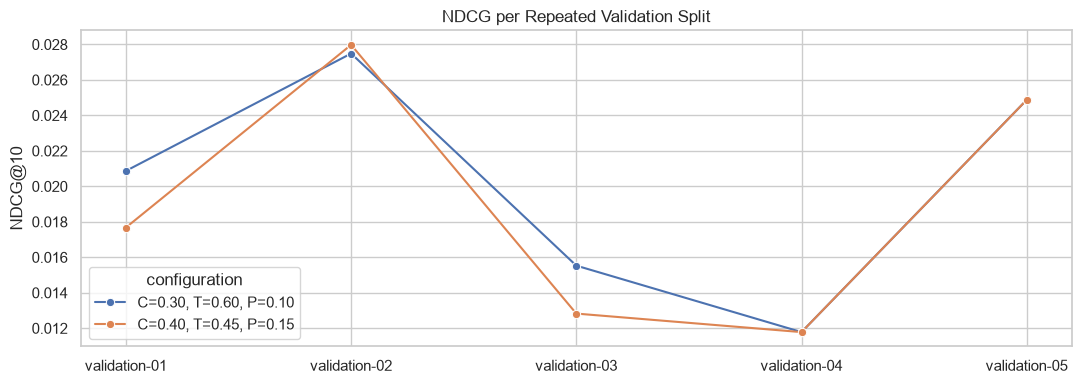

,split_id,configuration,ndcg
0,validation-01,"C=0.30, T=0.60, P=0.10",0.020869
1,validation-02,"C=0.30, T=0.60, P=0.10",0.027487
2,validation-03,"C=0.30, T=0.60, P=0.10",0.015528
3,validation-04,"C=0.30, T=0.60, P=0.10",0.011781
4,validation-05,"C=0.30, T=0.60, P=0.10",0.024871
5,validation-01,"C=0.40, T=0.45, P=0.15",0.017676
6,validation-02,"C=0.40, T=0.45, P=0.15",0.027976
7,validation-03,"C=0.40, T=0.45, P=0.15",0.012825
8,validation-04,"C=0.40, T=0.45, P=0.15",0.011781
9,validation-05,"C=0.40, T=0.45, P=0.15",0.024871


In [22]:
if benchmark_payload is not None:
    validation_records = []
    for configuration_record in benchmark_payload["validation"]["aggregate_by_config"]:
        label = weight_label(configuration_record)
        for split in configuration_record["per_split"]:
            validation_records.append(
                {
                    "split_id": split["split_id"],
                    "configuration": label,
                    "ndcg": split["end_to_end_metrics"][f"ndcg_at_{TOP_K}"],
                }
            )
    validation_by_split = pd.DataFrame(validation_records)
    fig, ax = plt.subplots(figsize=(11, 4))
    sns.lineplot(
        data=validation_by_split,
        x="split_id",
        y="ndcg",
        hue="configuration",
        marker="o",
        ax=ax,
    )
    ax.set(title="NDCG per Repeated Validation Split", xlabel="", ylabel=f"NDCG@{TOP_K}")
    plt.tight_layout()
    plt.show()
    display(validation_by_split)

Pada label konfigurasi, C berarti collaborative, T berarti content, dan P berarti
popularity. Challenger unggul pada split 1 dan 3, baseline unggul pada split 2,
sedangkan split 4 dan 5 berakhir sama. Hasil yang berubah antar-split menunjukkan
bahwa satu nilai rata-rata belum cukup untuk memilih konfigurasi.

NDCG bukan satu-satunya hal yang diperiksa. Coverage menunjukkan seberapa luas
katalog muncul dalam rekomendasi, sedangkan intra-list diversity menunjukkan
seberapa berbeda buku-buku dalam satu daftar. Novelty mengukur kecenderungan
merekomendasikan buku yang tidak terlalu populer, sementara popularity share
menunjukkan porsi rekomendasi yang berasal dari 10% buku terpopuler. Nilai berikut
merupakan rata-rata dari lima validation split.

In [23]:
if benchmark_payload is not None:
    diagnostic_rows = []
    for repeat in benchmark_payload["validation"]["repeats"]:
        for configuration in repeat["configurations"]:
            diagnostic = configuration["diagnostics"]
            diagnostic_rows.append(
                {
                    "configuration": weight_label(configuration),
                    "split_id": repeat["split_id"],
                    f"coverage@{TOP_K}": diagnostic[f"catalog_coverage_at_{TOP_K}"],
                    f"intra-list diversity@{TOP_K}": diagnostic[
                        f"intra_list_diversity_at_{TOP_K}"
                    ],
                    f"novelty@{TOP_K}": diagnostic[f"novelty_at_{TOP_K}"],
                    f"top-10% popularity share@{TOP_K}": diagnostic[
                        f"top_10pct_popularity_share_at_{TOP_K}"
                    ],
                }
            )

    diagnostic_by_split = pd.DataFrame(diagnostic_rows)
    diagnostic_summary = (
        diagnostic_by_split.drop(columns="split_id")
        .groupby("configuration", sort=False, as_index=False)
        .mean()
    )
    display(diagnostic_summary.round(4))

,configuration,coverage@10,intra-list diversity@10,novelty@10,top-10% popularity share@10
0,"C=0.30, T=0.60, P=0.10",0.1484,0.8780,8.4773,0.7028
1,"C=0.40, T=0.45, P=0.15",0.1412,0.8914,8.4563,0.7056


Challenger 0,30 / 0,60 / 0,10 memiliki coverage dan novelty sedikit lebih tinggi.
Baseline 0,40 / 0,45 / 0,15 memiliki intra-list diversity lebih tinggi, sedangkan
porsi buku sangat populer keduanya hampir sama. Hasil diagnostic ini hanya membantu
melihat karakter masing-masing konfigurasi. Keputusan mengganti baseline tetap
ditentukan oleh hasil NDCG dan selection gate.

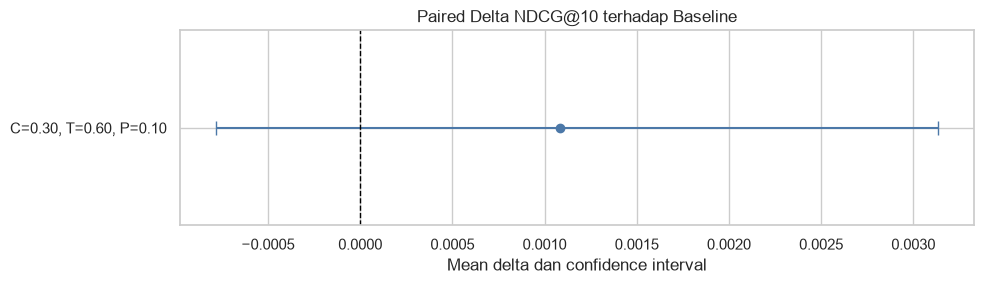

,config_id,mean_delta,lower,upper,selection_rate,passes_gate,configuration
0,cw0.300000000000_ct0.600000000000_pw0.100000000000,0.001081,-0.000782,0.003134,0.4,False,"C=0.30, T=0.60, P=0.10"


,decision,baseline_config_id,selected_config_id,minimum_delta,minimum_selection_rate
0,retain_baseline,cw0.400000000000_ct0.450000000000_pw0.150000000000,cw0.400000000000_ct0.450000000000_pw0.150000000000,0.0,0.6


In [23]:
if benchmark_payload is not None:
    selection = benchmark_payload["selection"]
    selection_rows = []
    paired = benchmark_payload["validation"]["paired_deltas_vs_baseline"]
    for config_id, evidence in paired.items():
        interval = evidence["end_to_end"][f"ndcg_at_{TOP_K}"]
        selection_rows.append(
            {
                "config_id": config_id,
                "mean_delta": interval["mean"],
                "lower": interval["lower"],
                "upper": interval["upper"],
                "selection_rate": evidence["selection_rate"],
                "passes_gate": config_id == selection["selected_config_id"]
                and selection["decision"] != "retain_baseline",
            }
        )
    selection_frame = pd.DataFrame(selection_rows)
    config_labels = {
        record["config_id"]: weight_label(record)
        for record in benchmark_payload["parameters"]["weight_configs"]
    }
    selection_frame["configuration"] = selection_frame["config_id"].map(config_labels)
    if not selection_frame.empty:
        fig, ax = plt.subplots(figsize=(10, 3))
        means = selection_frame["mean_delta"].to_numpy(dtype=float)
        lower = selection_frame["lower"].to_numpy(dtype=float)
        upper = selection_frame["upper"].to_numpy(dtype=float)
        ax.errorbar(
            means,
            selection_frame["configuration"],
            xerr=np.vstack([means - lower, upper - means]),
            fmt="o",
            color="#4C78A8",
            capsize=5,
        )
        ax.axvline(
            selection["min_delta"],
            color="black",
            linestyle="--",
            linewidth=1,
            label=f"minimum delta = {selection['min_delta']:.4f}",
        )
        ax.set(
            title=f"Paired Delta NDCG@{TOP_K} terhadap Baseline",
            xlabel="Mean delta dan confidence interval",
            ylabel="",
        )
        ax.legend(loc="best")
        plt.tight_layout()
        plt.show()
    display(selection_frame)
    display(
        pd.DataFrame(
            {
                "decision": [selection["decision"]],
                "baseline_config_id": [selection["baseline_config_id"]],
                "selected_config_id": [selection["selected_config_id"]],
                "minimum_delta": [selection["min_delta"]],
                "minimum_selection_rate": [selection["min_selection_rate"]],
            }
        )
    )

Titik pada grafik menunjukkan rata-rata selisih NDCG challenger terhadap baseline,
sedangkan garis horizontal menunjukkan confidence interval. Garis putus-putus
menandai batas minimum peningkatan, yaitu nol.

Rata-rata NDCG challenger lebih tinggi 0,00108, tetapi confidence interval-nya
berada pada -0,00078 hingga 0,00313 dan masih melewati nol. Challenger juga hanya
unggul pada 40% split, di bawah syarat 60%. Karena peningkatannya belum konsisten,
baseline tetap dipakai.

In [24]:
if benchmark_payload is not None:
    fixed_test = benchmark_payload["fixed_test"]
    fixed_availability = fixed_test["availability"]
    fixed_funnel = pd.DataFrame(
        {
            "stage": [
                "sampled",
                "target available",
                "history evaluable",
                "personalization evaluable",
            ],
            "holdouts": [
                fixed_availability["sampled_holdouts"],
                fixed_availability["candidate_available_holdouts"],
                fixed_availability["history_evaluable_holdouts"],
                fixed_availability["personalization_evaluable_holdouts"],
            ],
        }
    )
    fixed_metrics = pd.DataFrame(
        [
            {
                "configuration": weight_label(record),
                "sampled_holdouts": record["sampled_holdouts"],
                "conditional_holdouts": record["conditional_holdouts"],
                **record["end_to_end_metrics"],
            }
            for record in fixed_test["aggregate_by_config"]
        ]
    )
    display(fixed_funnel)
    display(fixed_metrics)

,stage,holdouts
0,sampled,200
1,target available,46
2,history evaluable,23
3,personalization evaluable,19


,configuration,sampled_holdouts,conditional_holdouts,precision_at_10,recall_at_10,hit_rate_at_10,map_at_10,mrr_at_10,ndcg_at_10
0,"C=0.40, T=0.45, P=0.15",200,19,0.001,0.01,0.01,0.005,0.005,0.006309


Karena challenger tidak lolos validation gate, fixed test hanya dibuka untuk
baseline. Dari 200 kasus, 46 target tersedia di katalog dan 19 kasus dapat menilai
personalisasi. Baseline memperoleh HitRate@10 sebesar 1% dan NDCG@10 sebesar
0,00631. Hasil ini tidak membuktikan baseline mengalahkan challenger di fixed test
karena challenger memang tidak diuji di sana.

## 11. Eksperimen Kapasitas Katalog

Bagian ini menguji apakah jumlah **candidate books** perlu diperbesar. Katalog yang
lebih besar dapat membuat buku relevan lebih sering masuk kandidat, tetapi juga
menambah waktu rekomendasi dan ukuran model. Karena itu, manfaat dan biayanya perlu
dibandingkan sebelum konfigurasi baru digunakan.

Kita membandingkan tiga ukuran **interaction/content catalog**: 1.000 / 3.000,
3.000 / 10.000, dan 5.000 / 20.000. Holdout, bobot hybrid, neighbors, filter,
dan threshold dibuat tetap agar perbedaannya benar-benar berasal dari ukuran katalog.

Pada label 1.000 / 3.000, sebanyak 1.000 buku digunakan untuk collaborative di
dalam total 3.000 candidate books. Jadi, jumlahnya bukan 4.000 buku. Dua konfigurasi
lainnya dibaca dengan cara yang sama.

In [25]:
catalog_summary = read_catalog_benchmark_summary(
    CATALOG_BENCHMARK_SUMMARY,
    expected_algorithms=evaluation_algorithm_contract(),
)
catalog_parameters = catalog_summary["parameters"]
catalog_source = catalog_summary["source"]
if int(catalog_parameters["k"]) != TOP_K:
    raise ValueError(
        "Catalog benchmark summary k does not match the notebook Top-K configuration."
    )
notebook_source_fingerprint = fingerprint_dataset(
    cleaned.books,
    cleaned.ratings,
    cleaned.users,
).fingerprint
catalog_fingerprint_matches = (
    catalog_source["source_dataset_fingerprint"] == notebook_source_fingerprint
)
catalog_portfolio_scale = (
    int(catalog_parameters["validation_users"]) >= 200
    and int(catalog_parameters["test_users"]) >= 200
    and int(catalog_parameters["repetitions"]) >= 5
    and int(catalog_parameters["bootstrap_resamples"]) >= 2_000
)
display(
    pd.DataFrame(
        {
            "field": [
                "summary",
                "protocol",
                "raw artifact SHA-256",
                "source dataset fingerprint",
                "notebook dataset fingerprint",
                "dataset lineage",
                "validation users / repeat",
                "fixed-test users",
                "repetitions",
                "selection confidence",
                "evidence label",
            ],
            "value": [
                display_path(CATALOG_BENCHMARK_SUMMARY, PROJECT_ROOT),
                catalog_summary["protocol"],
                catalog_source["raw_artifact_sha256"],
                catalog_source["source_dataset_fingerprint"],
                notebook_source_fingerprint,
                "MATCH" if catalog_fingerprint_matches else "EXTERNAL EVIDENCE / MISMATCH",
                catalog_parameters["validation_users"],
                catalog_parameters["test_users"],
                catalog_parameters["repetitions"],
                catalog_parameters["selection_confidence_level"],
                "PORTFOLIO-SCALE" if catalog_portfolio_scale else "SMOKE/PILOT",
            ],
        }
    )
)
if not catalog_fingerprint_matches:
    display(
        Markdown(
            "**Peringatan lineage:** summary berasal dari dataset berbeda. Angka benchmark "
            "ditampilkan sebagai external evidence dan tidak boleh dianggap sebagai hasil "
            "pengukuran dataset yang sedang dibuka notebook."
        )
    )

,field,value
0,summary,docs/evidence/catalog_size_benchmark_summary.json
1,protocol,canonical_work_fixed_test_repeated_validation_paired_catalog_v1
2,raw artifact SHA-256,ffeef9e038f50e164097f45a5b8603896ee564d78b9a2b22d0d600913adbfc45
3,source dataset fingerprint,796b9fc00f906765c0201c0527f0eb2d40cfc4d877b6d525e83a552b20820146
4,notebook dataset fingerprint,796b9fc00f906765c0201c0527f0eb2d40cfc4d877b6d525e83a552b20820146
5,dataset lineage,MATCH
6,validation users / repeat,200
7,fixed-test users,200
8,repetitions,5
9,selection confidence,0.975


Fingerprint dataset benchmark sama dengan dataset notebook, sehingga hasilnya
memang berasal dari data yang sedang dibahas. Benchmark menggunakan lima validation
split × 200 kasus, 200 kasus fixed test, dan selection confidence 97,5%.

In [26]:
catalog_selection = catalog_summary["selection"]
catalog_evidence_by_id = {
    record["config_id"]: record for record in catalog_selection["candidate_evidence"]
}
catalog_rows = []
for record in catalog_summary["validation"]["aggregate_by_config"]:
    config_id = record["config_id"]
    evidence = catalog_evidence_by_id.get(config_id, {})
    is_baseline = config_id == catalog_parameters["baseline_config_id"]
    resources = record["resources"]
    diagnostics = record["common_reference_diagnostics"]
    catalog_rows.append(
        {
            "config_id": config_id,
            "catalog": catalog_label(record),
            "role": "baseline/reference" if is_baseline else "challenger",
            f"NDCG@{TOP_K}": record["end_to_end_metrics"][f"ndcg_at_{TOP_K}"],
            f"HitRate@{TOP_K}": record["end_to_end_metrics"][f"hit_rate_at_{TOP_K}"],
            "content retention": record["availability"]["content_retention_rate"],
            "personalization retention": record["availability"][
                "personalization_retention_rate"
            ],
            "unique recommended works": diagnostics["unique_recommended_works_at_k"],
            "coverage vs common reference": diagnostics[
                "coverage_vs_common_reference_at_k"
            ],
            f"novelty@{TOP_K}": diagnostics[f"novelty_at_{TOP_K}"],
            "p95 latency ms": resources["warm_inference"]["p95_ms"],
            "serialized model MB": (
                resources["model_proxy"]["serialized_model_bytes"] / 1_000_000
            ),
            "p95 latency ratio": evidence.get("p95_latency_ratio", 1.0),
            "serialized model ratio": evidence.get("serialized_model_ratio", 1.0),
            "quality gate": evidence.get("passes_quality", pd.NA),
            "reach gate": evidence.get("passes_reach", pd.NA),
            "resource gate": evidence.get("passes_resources", pd.NA),
            "promotion status": (
                "baseline/reference"
                if is_baseline
                else ("passed" if evidence["passes"] else "not promoted")
            ),
        }
    )
catalog_results = pd.DataFrame(catalog_rows)
display(catalog_results.round(4))

,config_id,catalog,role,NDCG@10,HitRate@10,content retention,personalization retention,unique recommended works,coverage vs common reference,novelty@10,p95 latency ms,serialized model MB,p95 latency ratio,serialized model ratio,quality gate,reach gate,resource gate,promotion status
0,ib1000_cb3000,"1,000 / 3,000",baseline/reference,0.0187,0.028,0.247,0.126,391.0,0.0217,11.2977,105.1033,9.6465,1.0000,1.0000,<NA>,<NA>,<NA>,baseline/reference
1,ib3000_cb10000,"3,000 / 10,000",challenger,0.0221,0.035,0.388,0.233,682.2,0.0378,12.0351,232.7387,24.8939,2.2144,2.5806,False,True,True,not promoted
2,ib5000_cb20000,"5,000 / 20,000",challenger,0.0218,0.035,0.464,0.290,818.2,0.0453,12.4580,408.8601,41.8583,3.8901,4.3392,False,True,False,not promoted


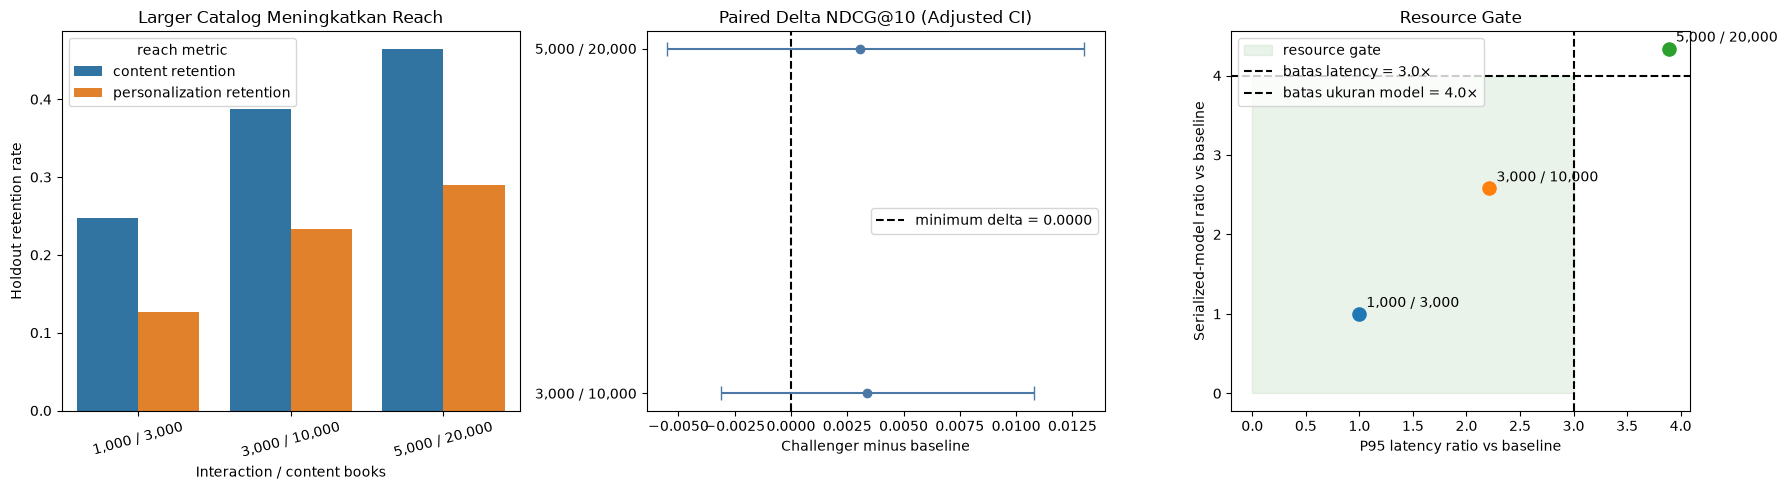

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

reach_long = catalog_results.melt(
    id_vars="catalog",
    value_vars=["content retention", "personalization retention"],
    var_name="reach metric",
    value_name="rate",
)
sns.barplot(
    data=reach_long,
    x="catalog",
    y="rate",
    hue="reach metric",
    ax=axes[0],
)
axes[0].set(
    title="Larger Catalog Meningkatkan Reach",
    xlabel="Interaction / content books",
    ylabel="Holdout retention rate",
)
axes[0].tick_params(axis="x", rotation=15)

paired_catalog_deltas = catalog_summary["validation"]["paired_deltas_vs_baseline"]
delta_rows = []
for config_id, evidence in paired_catalog_deltas.items():
    interval = evidence["end_to_end"][f"ndcg_at_{TOP_K}"]
    catalog_record = next(
        record
        for record in catalog_summary["parameters"]["catalog_configs"]
        if record["config_id"] == config_id
    )
    delta_rows.append(
        {
            "catalog": catalog_label(catalog_record),
            "mean": interval["mean"],
            "lower": interval["lower"],
            "upper": interval["upper"],
        }
    )
delta_frame = pd.DataFrame(delta_rows)
axes[1].axvline(
    catalog_selection["min_delta"],
    color="black",
    linestyle="--",
    label=f"minimum delta = {catalog_selection['min_delta']:.4f}",
)
if delta_frame.empty:
    axes[1].text(
        0.5,
        0.5,
        "Tidak ada challenger pada summary",
        ha="center",
        va="center",
        transform=axes[1].transAxes,
    )
    axes[1].set_yticks([])
else:
    delta_y = np.arange(len(delta_frame))
    axes[1].errorbar(
        delta_frame["mean"],
        delta_y,
        xerr=np.vstack(
            [
                delta_frame["mean"] - delta_frame["lower"],
                delta_frame["upper"] - delta_frame["mean"],
            ]
        ),
        fmt="o",
        color="#4C78A8",
        capsize=5,
    )
    axes[1].set_yticks(delta_y, delta_frame["catalog"])
axes[1].set(
    title=f"Paired Delta NDCG@{TOP_K} (Adjusted CI)",
    xlabel="Challenger minus baseline",
    ylabel="",
)
axes[1].legend(loc="best")

axes[2].add_patch(
    plt.Rectangle(
        (0, 0),
        catalog_selection["max_latency_ratio"],
        catalog_selection["max_serialized_model_ratio"],
        color="#59A14F",
        alpha=0.12,
        label="resource gate",
    )
)
for _, row in catalog_results.iterrows():
    axes[2].scatter(
        row["p95 latency ratio"],
        row["serialized model ratio"],
        s=90,
    )
    axes[2].annotate(
        row["catalog"],
        (
            row["p95 latency ratio"],
            row["serialized model ratio"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )
axes[2].axvline(
    catalog_selection["max_latency_ratio"],
    color="black",
    linestyle="--",
    label=f"batas latency = {catalog_selection['max_latency_ratio']:.1f}×",
)
axes[2].axhline(
    catalog_selection["max_serialized_model_ratio"],
    color="black",
    linestyle="--",
    label=(
        f"batas ukuran model = "
        f"{catalog_selection['max_serialized_model_ratio']:.1f}×"
    ),
)
axes[2].set(
    title="Resource Gate",
    xlabel="P95 latency ratio vs baseline",
    ylabel="Serialized-model ratio vs baseline",
)
axes[2].legend(loc="upper left")
plt.tight_layout()
plt.show()

Grafik kiri menunjukkan katalog lebih besar membuat lebih banyak target tersedia.
Grafik tengah menunjukkan rata-rata NDCG terlihat naik, tetapi confidence interval
kedua challenger masih melewati nol sehingga peningkatannya belum pasti. Grafik
kanan menunjukkan katalog sedang masih berada di dalam batas biaya, sedangkan
katalog terbesar melewati batas latency dan ukuran model.

In [28]:
catalog_fixed_test = catalog_summary["fixed_test"]
catalog_decision_record = pd.DataFrame(
    {
        "field": [
            "validation decision",
            "validation selected config",
            "fixed-test evaluated configs",
            "deployment decision",
            "deployment config",
        ],
        "value": [
            catalog_selection["decision"],
            catalog_selection["selected_config_id"],
            ", ".join(catalog_fixed_test["evaluated_config_ids"]),
            catalog_summary["deployment"]["decision"],
            catalog_summary["deployment"]["deployment_config_id"],
        ],
    }
)
catalog_gate_columns = [
    "config_id",
    "paired_delta_lower",
    "selection_rate",
    "content_retention_delta",
    "personalization_retention_delta",
    "p95_latency_ratio",
    "serialized_model_ratio",
    "passes_quality",
    "passes_reach",
    "passes_resources",
    "passes",
]
catalog_gate_table = pd.DataFrame(
    catalog_selection["candidate_evidence"],
    columns=catalog_gate_columns,
)
catalog_fixed_metrics = pd.DataFrame(
    [
        {
            "config_id": record["config_id"],
            f"NDCG@{TOP_K}": record["end_to_end_metrics"][f"ndcg_at_{TOP_K}"],
            f"HitRate@{TOP_K}": record["end_to_end_metrics"][f"hit_rate_at_{TOP_K}"],
            "content retention": record["availability"]["content_retention_rate"],
            "personalization retention": record["availability"][
                "personalization_retention_rate"
            ],
        }
        for record in catalog_fixed_test["aggregate_by_config"]
    ]
)
display(catalog_gate_table.round(4))
display(catalog_decision_record)
display(catalog_fixed_metrics.round(4))

,config_id,paired_delta_lower,selection_rate,content_retention_delta,personalization_retention_delta,p95_latency_ratio,serialized_model_ratio,passes_quality,passes_reach,passes_resources,passes
0,ib3000_cb10000,-0.0031,0.8,0.141,0.107,2.2144,2.5806,False,True,True,False
1,ib5000_cb20000,-0.0055,0.6,0.217,0.164,3.8901,4.3392,False,True,False,False


,field,value
0,validation decision,retain_baseline
1,validation selected config,ib1000_cb3000
2,fixed-test evaluated configs,ib1000_cb3000
3,deployment decision,retain_baseline
4,deployment config,ib1000_cb3000


,config_id,NDCG@10,HitRate@10,content retention,personalization retention
0,ib1000_cb3000,0.0063,0.01,0.23,0.095


In [29]:
if catalog_selection["decision"] == "retain_baseline":
    catalog_decision_text = (
        "Kedua katalog yang lebih besar lolos reach gate. Katalog sedang lolos "
        "resource gate tetapi gagal quality gate, sedangkan katalog terbesar gagal "
        "quality dan resource gate. Karena tidak ada challenger yang lolos seluruh "
        "gate, baseline tetap digunakan. Fixed test hanya mengevaluasi baseline; ini "
        "bukan bukti bahwa baseline mengalahkan challenger karena challenger memang "
        "tidak diuji di sana."
    )
else:
    selected_catalog = next(
        record
        for record in catalog_parameters["catalog_configs"]
        if record["config_id"] == catalog_selection["selected_config_id"]
    )
    catalog_decision_text = (
        f"Challenger **{catalog_label(selected_catalog)}** melewati seluruh validation "
        "gate dan menjadi satu-satunya challenger yang boleh dibuka bersama baseline "
        "pada fixed test. Keputusan deployment di bawah tetap mengikuti fixed-test evidence."
    )
display(
    Markdown(
        catalog_decision_text
        + "\n\nLatency dan ukuran model dibandingkan sebagai rasio dalam run yang sama. "
        "Ukuran file model bukan ukuran peak RAM saat proses berjalan."
    )
)

Kedua katalog yang lebih besar lolos reach gate. Katalog sedang lolos resource gate tetapi gagal quality gate, sedangkan katalog terbesar gagal quality dan resource gate. Karena tidak ada challenger yang lolos seluruh gate, baseline tetap digunakan. Fixed test hanya mengevaluasi baseline; ini bukan bukti bahwa baseline mengalahkan challenger karena challenger memang tidak diuji di sana.

Latency dan ukuran model dibandingkan sebagai rasio dalam run yang sama. Ukuran file model bukan ukuran peak RAM saat proses berjalan.

## 12. Experiment-to-Serving

`RecommenderService.load` memverifikasi manifest, checksum SHA-256, tipe model,
kompatibilitas runtime, algorithm version, schema, dan dataset fingerprint sebelum
memberi akses inference. Ini adalah boundary yang sama dengan API dan Streamlit.

In [30]:
service = RecommenderService.load(MODEL_ARTIFACT)
service_info = service.model_info()
service_manifest = service.manifest

lineage = pd.DataFrame(
    {
        "field": [
            "artifact_id",
            "model_type",
            "created_at",
            "code_sha",
            "code_dirty",
            "dataset_fingerprint",
            "books",
            "ratings",
            "artifact_size_mb",
        ],
        "value": [
            service_info["artifact_id"],
            service_info["model_type"],
            service_info["created_at"],
            service_info["code_sha"],
            service_manifest.code_dirty,
            service_info["dataset_fingerprint"],
            service_info["books"],
            service_info["ratings"],
            round(MODEL_ARTIFACT.stat().st_size / (1024**2), 2),
        ],
    }
)
display(lineage)

,field,value
0,artifact_id,hybrid-5b00e40e8959
1,model_type,hybrid
2,created_at,2026-07-11T03:25:37.936712+00:00
3,code_sha,eaa3cefe04961a09e2eb47bf2e19d8bf2c3730fc
4,code_dirty,False
5,dataset_fingerprint,5e186967bc72dacdd2fecebf228003d3b6da42f9432b8260c984b0acb9b2ef68
6,books,3000
7,ratings,52109
8,artifact_size_mb,9.21


In [31]:
notebook_training_fingerprint = fingerprint_dataset(
    dataset.books,
    dataset.ratings,
    dataset.users,
).fingerprint
serving_config = service_manifest.training_config
parity = pd.DataFrame(
    {
        "parameter": [
            "max_books",
            "max_content_books",
            "neighbors",
            "positive_rating_threshold",
            "collaborative_weight",
            "content_weight",
            "popularity_weight",
            "training_dataset_fingerprint",
        ],
        "notebook": [
            MAX_BOOKS,
            MAX_CONTENT_BOOKS,
            N_NEIGHBORS,
            POSITIVE_RATING_THRESHOLD,
            0.40,
            0.45,
            0.15,
            notebook_training_fingerprint,
        ],
        "serving": [
            required_config_value(serving_config, "max_books"),
            required_config_value(serving_config, "max_content_books"),
            required_config_value(serving_config, "neighbors"),
            required_config_value(serving_config, "positive_rating_threshold"),
            required_config_value(serving_config, "collaborative_weight"),
            required_config_value(serving_config, "content_weight"),
            required_config_value(serving_config, "popularity_weight"),
            required_config_value(service_manifest.dataset, "fingerprint"),
        ],
    }
)
parity["matches"] = [
    parity_value_matches(notebook_value, serving_value)
    for notebook_value, serving_value in zip(
        parity["notebook"],
        parity["serving"],
        strict=True,
    )
]
display(parity)

,parameter,notebook,serving,matches
0,max_books,1000,1000,True
1,max_content_books,3000,3000,True
2,neighbors,50,50,True
3,positive_rating_threshold,8.0,8.0,True
4,collaborative_weight,0.4,0.4,True
5,content_weight,0.45,0.45,True
6,popularity_weight,0.15,0.15,True
7,training_dataset_fingerprint,5e186967bc72dacdd2fecebf228003d3b6da42f9432b8260c984b0acb9b2ef68,5e186967bc72dacdd2fecebf228003d3b6da42f9432b8260c984b0acb9b2ef68,True


Bundle aktif berisi model hybrid dengan 3.000 buku dan 52.109 rating. Seluruh
konfigurasi notebook mulai dari ukuran katalog, jumlah neighbors, batas rating
positif, bobot hybrid, hingga fingerprint dataset adalah konfigurasi serving yg dipakai.

In [32]:
deployment_config_id = catalog_summary["deployment"]["deployment_config_id"]
deployment_catalog = next(
    record
    for record in catalog_parameters["catalog_configs"]
    if record["config_id"] == deployment_config_id
)
deployment_weights = catalog_parameters["hybrid_weights"]
candidate_pool_parameter = signature(service.model.recommend_for_user).parameters.get(
    "candidate_pool_size"
)
serving_candidate_pool_size = (
    candidate_pool_parameter.default
    if candidate_pool_parameter is not None
    and candidate_pool_parameter.default is not Parameter.empty
    else MISSING_CONFIG_VALUE
)
serving_dynamic_weights = (
    not bool(serving_config["disable_dynamic_weights"])
    if "disable_dynamic_weights" in serving_config
    else MISSING_CONFIG_VALUE
)
catalog_serving_parity = pd.DataFrame(
    {
        "parameter": [
            "max_books",
            "max_content_books",
            "neighbors",
            "hybrid_candidate_pool_size",
            "positive_rating_threshold",
            "dynamic_weights",
            "min_user_ratings",
            "min_book_ratings",
            "max_ratings",
            "deployment_random_state",
            "collaborative_weight",
            "content_weight",
            "popularity_weight",
        ],
        "benchmark deployment decision": [
            deployment_catalog["max_interaction_books"],
            deployment_catalog["max_content_books"],
            catalog_parameters["neighbors"],
            catalog_parameters["hybrid_candidate_pool_size"],
            catalog_parameters["positive_rating_threshold"],
            catalog_parameters["hybrid_dynamic_weights"],
            catalog_parameters["min_user_ratings"],
            catalog_parameters["min_book_ratings"],
            catalog_parameters["max_ratings"],
            catalog_parameters["test_random_state"],
            deployment_weights["collaborative_weight"],
            deployment_weights["content_weight"],
            deployment_weights["popularity_weight"],
        ],
        "serving bundle": [
            required_config_value(serving_config, "max_books"),
            required_config_value(serving_config, "max_content_books"),
            required_config_value(serving_config, "neighbors"),
            serving_candidate_pool_size,
            required_config_value(serving_config, "positive_rating_threshold"),
            serving_dynamic_weights,
            required_config_value(serving_config, "min_user_ratings"),
            required_config_value(serving_config, "min_book_ratings"),
            required_config_value(serving_config, "max_ratings"),
            required_config_value(serving_config, "random_state"),
            required_config_value(serving_config, "collaborative_weight"),
            required_config_value(serving_config, "content_weight"),
            required_config_value(serving_config, "popularity_weight"),
        ],
    }
)
catalog_serving_parity["matches"] = [
    parity_value_matches(benchmark_value, serving_value)
    for benchmark_value, serving_value in zip(
        catalog_serving_parity["benchmark deployment decision"],
        catalog_serving_parity["serving bundle"],
        strict=True,
    )
]
display(
    pd.DataFrame(
        {
            "field": [
                "catalog benchmark raw SHA-256",
                "catalog benchmark decision",
                "deployment config",
                "serving artifact id",
                "benchmark embedded in serving manifest",
            ],
            "value": [
                catalog_source["raw_artifact_sha256"],
                catalog_summary["deployment"]["decision"],
                deployment_config_id,
                service_info["artifact_id"],
                (
                    "no — existing serving bundle retained"
                    if catalog_summary["deployment"]["decision"] == "retain_baseline"
                    else "no — benchmark decision post-dates this serving bundle"
                ),
            ],
        }
    )
)
display(catalog_serving_parity)

,field,value
0,catalog benchmark raw SHA-256,ffeef9e038f50e164097f45a5b8603896ee564d78b9a2b22d0d600913adbfc45
1,catalog benchmark decision,retain_baseline
2,deployment config,ib1000_cb3000
3,serving artifact id,hybrid-5b00e40e8959
4,benchmark embedded in serving manifest,no — existing serving bundle retained


,parameter,benchmark deployment decision,serving bundle,matches
0,max_books,1000,1000,True
1,max_content_books,3000,3000,True
2,neighbors,50,50,True
3,hybrid_candidate_pool_size,500,500,True
4,positive_rating_threshold,8.0,8.0,True
5,dynamic_weights,True,True,True
6,min_user_ratings,2,2,True
7,min_book_ratings,2,2,True
8,max_ratings,None,None,True
9,deployment_random_state,42,42,True


In [33]:
catalog_serving_matches = bool(catalog_serving_parity["matches"].all())
if catalog_summary["deployment"]["decision"] == "retain_baseline":
    serving_lineage_text = (
        "Benchmark memutuskan untuk mempertahankan konfigurasi baseline, sehingga "
        "tidak ada model baru yang perlu dipromosikan. Status kecocokan seluruh "
        "parameter hasil keputusan benchmark dengan bundle serving aktif: "
        f"**{'MATCH' if catalog_serving_matches else 'MISMATCH'}**."
    )
else:
    serving_lineage_text = (
        "Benchmark memilih challenger. Sebelum model itu digunakan, seluruh parameternya "
        "harus sama dengan bundle serving aktif. Hasil pemeriksaan: "
        f"**{'MATCH' if catalog_serving_matches else 'MISMATCH — bundle perlu dibangun dan dipromosikan ulang'}**."
    )
display(Markdown(serving_lineage_text))

Benchmark memutuskan untuk mempertahankan konfigurasi baseline, sehingga tidak ada model baru yang perlu dipromosikan. Status kecocokan seluruh parameter hasil keputusan benchmark dengan bundle serving aktif: **MATCH**.

### Uji Singkat Setelah Model Dimuat

Setelah model dimuat, kita perlu memastikan service dapat menghasilkan rekomendasi
tanpa error. Model kemudian dipanggil 10 kali sambil mencatat waktu responsnya.
Pengujian singkat ini dilakukan pada mesin yang menjalankan notebook, sehingga
hasilnya belum mewakili kondisi produksi.

In [34]:
serving_user_id = int(service.ratings["user_id"].value_counts().index[0])
with threadpool_limits(limits=1):
    service.recommend_for_user(serving_user_id, top_n=TOP_K)
    latency_ms = []
    for _ in range(10):
        started = perf_counter()
        serving_recommendations = service.recommend_for_user(serving_user_id, top_n=TOP_K)
        latency_ms.append((perf_counter() - started) * 1_000)

serving_smoke = pd.DataFrame(
    {
        "metric": ["runs", "result rows", "mean latency ms", "p95 latency ms"],
        "value": [
            len(latency_ms),
            len(serving_recommendations),
            float(np.mean(latency_ms)),
            float(np.quantile(latency_ms, 0.95)),
        ],
    }
)
display(serving_smoke)
display(
    serving_recommendations[
        ["score", "source", "reason", "isbn", "book_title", "book_author"]
    ].head(5)
)

,metric,value
0,runs,10.000000
1,result rows,10.000000
2,mean latency ms,111.369970
3,p95 latency ms,149.580385


,score,source,reason,isbn,book_title,book_author
0,0.512362,collaborative,Item-rating patterns are similar to books the user rated 8/10 or higher.,0553250426,The Clan of the Cave Bear (Earth's Children (Paperback)),Jean M. Auel
1,0.491339,collaborative,Item-rating patterns are similar to books the user rated 8/10 or higher.,0375500510,Black and Blue : A Novel,ANNA QUINDLEN
2,0.448067,collaborative,Item-rating patterns are similar to books the user rated 8/10 or higher.,031298328X,Full Tilt (Janet Evanovich's Full Series),Janet Evanovich
3,0.426311,content,Metadata is similar to books the user rated 8/10 or higher.,0060930535,The Poisonwood Bible: A Novel,Barbara Kingsolver
4,0.423990,collaborative,Item-rating patterns are similar to books the user rated 8/10 or higher.,0451186362,Rose Madder,Stephen King


Sepuluh pemanggilan rekomendasi berhasil diselesaikan dan daftar hasil berisi 10
buku. P95 latency tercatat sekitar 149,6 ms pada mesin yang menjalankan notebook,
tetapi angka ini belum dapat dianggap sebagai jaminan latency di produksi.

## 13. Trade-off dan Pengujian Selanjutnya

| Pilihan | Kekuatan | Risiko utama |
| --- | --- | --- |
| Popularity | murah, selalu tersedia | nonpersonal, popularity bias |
| Collaborative | personal dari perilaku bersama | sparse/cold-start |
| Content | cold item dan item similarity | metadata dangkal/overspecialization |
| Hybrid | fallback dan beberapa sumber evidence | bobot serta operasi lebih kompleks |
| Katalog lebih besar | reach dan discovery meningkat | latency serta artifact membesar |

Evaluasi offline belum membuktikan bahwa pengguna nyata akan menyukai rekomendasinya.
Jika aplikasi sudah memiliki cukup pengguna, langkah berikutnya adalah melakukan
A/B test. Pembagian dilakukan berdasarkan pengguna agar orang yang sama selalu
mendapatkan versi model yang sama selama pengujian.

Keberhasilan utama dapat dilihat dari jumlah buku yang disimpan atau mulai dibaca.
Jumlah rekomendasi yang diklik dapat menjadi sinyal awal. Waktu respons, rekomendasi
kosong, penggunaan fallback, dan dominasi buku populer juga tetap dipantau agar
peningkatan satu metrik tidak merusak bagian lain. Pembelian baru dapat digunakan
sebagai ukuran jika transaksi memang dicatat dengan jelas.

## 14. Kesimpulan


Yang sudah ditunjukkan:

- popularity, collaborative, content, dan hybrid dapat dijalankan dalam pipeline
  yang sama;
- edisi lain dari buku yang disembunyikan ikut dikeluarkan dari data training untuk
  mencegah kebocoran;
- komposisi bobot hybrid dibandingkan melalui beberapa validation split sebelum
  baseline diuji pada fixed test;
- katalog yang lebih besar meningkatkan jumlah buku relevan yang dapat dijangkau,
  tetapi peningkatan kualitasnya belum konsisten dan biaya serving ikut bertambah;
- konfigurasi dan dataset pada bundle serving sama dengan yang diperiksa di notebook;
- model yang sudah dimuat dapat menghasilkan rekomendasi tanpa error.

Yang belum dapat disimpulkan:

- rekomendasi meningkatkan jumlah klik, buku yang disimpan, mulai dibaca, atau dibeli
  oleh pengguna nyata;
- performa model tetap stabil dari waktu ke waktu karena dataset tidak memiliki
  timestamp;
- sistem dapat menangani katalog berisi jutaan buku;
- konfigurasi challenger lebih baik daripada baseline karena hasil validation-nya
  belum konsisten.
